# Yeast metabolite → alopecia candidate GNN: v5 + v7 true end-to-end Colab notebook

이 notebook은 **외부 `v5.py`, `v7.py`를 실행하지 않는다.**  
기존 v5의 parsing / SMILES resolving / GNN ranking 코드와 v7의 pathway enrichment + null model validation 코드를 **셀 내부 함수와 실행 셀로 직접 구성**했다.

핵심 원칙:

1. **Core pipeline**: pathway, compound, drug-target, target-disease 파일만 사용해 GNN ranking을 만든다.
2. **Validation**: GNN top candidates가 특정 pathway에 random / degree-matched null보다 더 강하게 enrichment되는지 검정한다.
3. **Post-hoc only**: `real_drug_score.csv`는 학습, ranking, validation score에 절대 넣지 않고 마지막 annotation과 해석용 시각화에만 사용한다.

In [1]:
!pip install -q rdkit torch-geometric networkx scikit-learn tqdm openpyxl

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.1/37.1 MB 21.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 19.6 MB/s eta 0:00:00


In [2]:
import torch

pt_version = torch.__version__.split('+')[0]

if torch.version.cuda is not None:
    device_version = 'cu' + torch.version.cuda.replace('.', '')
else:
    device_version = 'cpu'

print(f"PyTorch 버전: {pt_version}, 환경: {device_version}")

!pip install torch_geometric
!pip install pyg_lib torch_scatter torch_sparse -f https://data.pyg.org/whl/torch-{pt_version}+{device_version}.html

PyTorch 버전: 2.10.0, 환경: cu128
Looking in links: https://data.pyg.org/whl/torch-2.10.0+cu128.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 17.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 72.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 45.4 MB/s eta 0:00:00


In [3]:

# ============================================================
# 0. Colab setup
# ============================================================
import os, sys, re, math, time, random, warnings, zipfile, shutil, subprocess
from pathlib import Path
from collections import defaultdict, Counter
from urllib.parse import quote

warnings.filterwarnings("ignore")
IN_COLAB = "google.colab" in sys.modules
PROJECT_DIR = Path("/content/yeast_alopecia_project") if IN_COLAB else Path.cwd() / "yeast_alopecia_project"
PROJECT_DIR.mkdir(parents=True, exist_ok=True)
os.chdir(PROJECT_DIR)

print("Project directory:", PROJECT_DIR)
print("Python:", sys.version.split()[0])

import numpy as np
import pandas as pd
import scipy.sparse as sp
import requests
import matplotlib.pyplot as plt
import networkx as nx

from IPython.display import display, HTML
from tqdm.auto import tqdm
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.stats import hypergeom

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import HeteroData
from torch_geometric.nn import HANConv
from torch_geometric.transforms import RandomLinkSplit
from torch_geometric.loader import LinkNeighborLoader

from rdkit import Chem, DataStructs
from rdkit.Chem import rdFingerprintGenerator, Descriptors

pd.set_option("display.max_columns", 80)
pd.set_option("display.max_rows", 80)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Torch:", torch.__version__)
print("Device:", DEVICE)

Project directory: /content/yeast_alopecia_project
Python: 3.12.13
Torch: 2.10.0+cu128
Device: cuda


In [35]:

# ============================================================
# 1. Upload required input files in Colab
# ============================================================
# Required files:
# - All-pathways-of-S-cerevisiae-S288c_cleaned_compounds*.txt
# - compound-inchikey.txt
# - All-compounds-of-S.-cerevisiae-S288c-2.txt
# - real_drug_target_edges.csv
# - real_target_disease_edges.csv
# Optional:
# - real_drug_score.csv

os.chdir(PROJECT_DIR)

if IN_COLAB:
    from google.colab import files
    print("Upload required files. You can upload individual files or one zip containing all files.")
    uploaded = files.upload()
    for name, data in uploaded.items():
        path = PROJECT_DIR / name
        with open(path, "wb") as f:
            f.write(data)
        if name.lower().endswith(".zip"):
            print("Extracting zip:", name)
            with zipfile.ZipFile(path, "r") as zf:
                zf.extractall(PROJECT_DIR)
else:
    print("Local mode: copy input files into", PROJECT_DIR)

# Flatten one-level nested folders produced by zip extraction.
for p in list(PROJECT_DIR.rglob("*")):
    if p.is_file() and p.parent != PROJECT_DIR:
        target = PROJECT_DIR / p.name
        if not target.exists():
            try:
                shutil.copy2(p, target)
            except Exception:
                pass

def find_one(patterns, required=True):
    if isinstance(patterns, str):
        patterns = [patterns]
    matches = []
    for pat in patterns:
        matches.extend(sorted(PROJECT_DIR.glob(pat)))
    # Prefer non-empty newest-looking file if duplicates exist.
    matches = [m for m in matches if m.is_file()]
    if not matches:
        if required:
            raise FileNotFoundError(f"Cannot find required file matching: {patterns}\nCurrent files: {[p.name for p in PROJECT_DIR.glob('*') if p.is_file()]}")
        return None
    return matches[0]

PATHWAY_FILE = find_one(["All-pathways-of-S-cerevisiae-S288c_cleaned_compounds*.txt", "*pathways*cleaned*compounds*.txt"])
INCHIKEY_FILE = find_one("compound-inchikey.txt")
COMPOUND_FILE = find_one("All-compounds-of-S.-cerevisiae-S288c-2.txt")
DRUG_TARGET_FILE = find_one("real_drug_target_edges.csv")
TARGET_DISEASE_FILE = find_one("real_target_disease_edges.csv")
REAL_DRUG_SCORE_FILE = find_one("real_drug_score.csv", required=False)

print("Resolved input files:")
for label, p in [
    ("PATHWAY_FILE", PATHWAY_FILE),
    ("INCHIKEY_FILE", INCHIKEY_FILE),
    ("COMPOUND_FILE", COMPOUND_FILE),
    ("DRUG_TARGET_FILE", DRUG_TARGET_FILE),
    ("TARGET_DISEASE_FILE", TARGET_DISEASE_FILE),
    ("REAL_DRUG_SCORE_FILE", REAL_DRUG_SCORE_FILE),
]:
    print(f"- {label}: {p.name if p else None}")

Upload required files. You can upload individual files or one zip containing all files.


Saving real_drug_score.csv to real_drug_score (1).csv
Resolved input files:
- PATHWAY_FILE: All-pathways-of-S-cerevisiae-S288c_cleaned_compounds(2).txt
- INCHIKEY_FILE: compound-inchikey.txt
- COMPOUND_FILE: All-compounds-of-S.-cerevisiae-S288c-2.txt
- DRUG_TARGET_FILE: real_drug_target_edges.csv
- TARGET_DISEASE_FILE: real_target_disease_edges.csv
- REAL_DRUG_SCORE_FILE: real_drug_score.csv


In [33]:

# ============================================================
# 2. Runtime configuration
# ============================================================
# For quick debugging in Colab, set FAST_TEST=True.
FAST_TEST = False

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# v5 core options
WALK_LENGTH = 20
CURRENCY_PCT = 95.0
TOP_K_TANIMOTO = 5
HIDDEN = 256
HEADS = 4
DROPOUT = 0.1
EPOCHS = 2 if FAST_TEST else 30
LR = 1e-3
BATCH_SIZE = 128
TOP_K_RANK = 100 if FAST_TEST else 300

# final evidence-calibrated ranking options
ALOPECIA_MODE = "AGA"   # AGA, AA, mixed
CANDIDATE_MIN_TANIMOTO = 0.25
TANIMOTO_MIDPOINT = 0.45
TANIMOTO_TEMPERATURE = 0.07
ARTIFACT_PENALTY_STRENGTH = 0.55

# v7 validation options
TOP_N_VALIDATION = 50 if FAST_TEST else 100
N_PERM = 50 if FAST_TEST else 1000
MIN_PATHWAY_SIZE = 3
MIN_HITS_FOR_ENRICHMENT = 2
ALPHA = 0.05

# SMILES resolving options
# local_first: use local SMILES in compound-inchikey first, then pathway SMILES, then optional web fetch.
METABOLITE_SMILES_MODE = "local_first"
FETCH_MISSING_METABOLITE_SMILES = False  # turn True only if Colab internet calls are acceptable
FETCH_DRUG_SMILES = True                 # drug ChEMBL/PubChem SMILES needed for Tanimoto edges
MAX_WORKERS = 5

print({
    "FAST_TEST": FAST_TEST,
    "EPOCHS": EPOCHS,
    "TOP_K_RANK": TOP_K_RANK,
    "TOP_N_VALIDATION": TOP_N_VALIDATION,
    "N_PERM": N_PERM,
    "DEVICE": str(DEVICE),
})

{'FAST_TEST': False, 'EPOCHS': 30, 'TOP_K_RANK': 300, 'TOP_N_VALIDATION': 100, 'N_PERM': 1000, 'DEVICE': 'cuda'}


## Part A. v5 core pipeline code in notebook cells

아래 셀들은 v5의 핵심을 notebook 내부 함수로 옮긴 것이다.  
특히 기존 parsing 문제였던 `H+`, `NAD+`, `(+)-allantoin` 같은 이름 내부의 `+`가 깨지지 않도록 reaction parser는 **공백이 있는 ` + `만 split**한다.

In [6]:

# ============================================================
# 3. Name cleaning, synonym mapping, reaction parsing
# ============================================================
COMPOUND_SYNONYMS = {
    "3-hydroxy-3-methylglutaryl-coa":  "(s)-3-hydroxy-3-methylglutaryl-coa",
    "mevalonic acid":                  "(r)-mevalonate",
    "mevalonate 5-phosphate":          "(r)-5-phosphomevalonate",
    "mevalonate 5-diphosphate":        "(r)-mevalonate diphosphate",
    "isopentenyl pyrophosphate":       "isopentenyl diphosphate",
    "dimethylallyl pyrophosphate":     "dimethylallyl diphosphate",
    "geranyl pyrophosphate":           "geranyl diphosphate",
    "farnesyl pyrophosphate":          "(2e,6e)-farnesyl diphosphate",
    "geranylgeranyl pyrophosphate":    "geranylgeranyl diphosphate",
    "2,3-oxidosqualene":               "(3s)-2,3-epoxy-2,3-dihydrosqualene",
    "farnesol":                        "(2e,6e)-farnesol",
}

def clean_html_name(x: str) -> str:
    """BioCyc-style names contain <i>, <sub>, &alpha; etc. Normalize them for matching."""
    if pd.isna(x):
        return ""
    s = str(x).strip()
    replacements = {
        "&alpha;": "alpha", "&beta;": "beta", "&gamma;": "gamma", "&delta;": "delta",
        "&omega;": "omega", "&rarr;": "→", "&lt;": "<", "&gt;": ">", "&amp;": "&",
        "<i>": "", "</i>": "", "<sup>": "", "</sup>": "", "<sub>": "", "</sub>": "",
    }
    for a, b in replacements.items():
        s = s.replace(a, b)
    s = re.sub(r"<[^>]+>", "", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

def norm_name(x: str) -> str:
    s = clean_html_name(x).lower().strip()
    s = re.sub(r"\s+", " ", s)
    s = COMPOUND_SYNONYMS.get(s, s)
    return s

def display_name(x: str) -> str:
    return clean_html_name(x).strip()

def parse_reaction_side(side: str):
    """Split reaction side on ' + ' only, not on charge signs such as H+ or NAD+."""
    out = []
    for tok in re.split(r"\s+\+\s+", str(side).strip()):
        tok = re.sub(r"^\d+\s+", "", tok.strip())
        tok = tok.strip()
        if tok:
            out.append(display_name(tok))
    return out

def split_compound_column(s: str):
    return [display_name(x) for x in str(s).split(" // ") if display_name(x)]

# Small test for the parser.
print(parse_reaction_side("ATP + NAD+ + 2 H+ + (S)-(+)-allantoin"))

['ATP', 'NAD+', 'H+', '(S)-(+)-allantoin']


In [7]:

# ============================================================
# 4. Load pathway table and pathway-compound membership
# ============================================================
def load_pathway_file(pathway_file: Path):
    df = pd.read_csv(pathway_file, sep="\t", dtype=str).fillna("")
    required = {"Pathways", "Compounds of pathway", "Reactions of pathway"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"Pathway file missing columns: {missing}; columns={list(df.columns)}")
    df["Pathways"] = df["Pathways"].apply(display_name)
    return df

def build_pathway_membership(pathway_df: pd.DataFrame):
    rows = []
    smiles_rows = []
    for _, row in pathway_df.iterrows():
        pathway = display_name(row["Pathways"])
        names = split_compound_column(row["Compounds of pathway"])
        smiles = [x.strip() for x in str(row.get("SMILES", "")).split(" // ")]
        for i, name in enumerate(names):
            rows.append({"pathway": pathway, "metabolite_name": name, "metabolite_key": norm_name(name)})
            if i < len(smiles) and smiles[i].strip():
                smiles_rows.append({"metabolite_name": name, "metabolite_key": norm_name(name), "pathway_smiles": smiles[i].strip()})
    membership = pd.DataFrame(rows).drop_duplicates()
    pathway_smiles_df = pd.DataFrame(smiles_rows).drop_duplicates("metabolite_key") if smiles_rows else pd.DataFrame(columns=["metabolite_name","metabolite_key","pathway_smiles"])
    return membership, pathway_smiles_df

def parse_reaction_rows(pathway_df: pd.DataFrame):
    rows = []
    for _, row in pathway_df.iterrows():
        pathway = display_name(row["Pathways"])
        for rxn in str(row["Reactions of pathway"]).split(" // "):
            rxn = rxn.strip()
            m = re.search(r"<-+>|<->|<-|->", rxn)
            if not m:
                continue
            sep = m.group()
            try:
                left_str, right_str = rxn.split(sep, 1)
            except ValueError:
                continue
            lefts = parse_reaction_side(left_str)
            rights = parse_reaction_side(right_str)
            all_compounds = sorted(set(lefts + rights), key=lambda z: z.lower())
            rows.append({
                "pathway": pathway,
                "reaction": rxn,
                "lefts": lefts,
                "rights": rights,
                "compounds": all_compounds,
            })
    return pd.DataFrame(rows)

pathway_df = load_pathway_file(PATHWAY_FILE)
pathway_membership, pathway_smiles_df = build_pathway_membership(pathway_df)
reaction_df = parse_reaction_rows(pathway_df)

print("Pathway rows:", len(pathway_df))
print("Unique pathways:", pathway_df["Pathways"].nunique())
print("Unique compounds in pathway column:", pathway_membership["metabolite_key"].nunique())
print("Parsed reactions:", len(reaction_df))
print("Pathway SMILES available:", pathway_smiles_df["metabolite_key"].nunique())

display(pathway_df.head(3))
display(pathway_membership.head(10))

Pathway rows: 345
Unique pathways: 344
Unique compounds in pathway column: 1133
Parsed reactions: 1458
Pathway SMILES available: 1085


,Pathways,Compounds of pathway,Reactions of pathway,SMILES
0,allantoin degradation to glyoxylate I,glyoxylate // H+ // (S)-(+)-allantoin // urea ...,allantoate + H2O -> (S)-ureidoglycolate + ur...,C(C(=O)[O-])=O // [H+] // C(=O)(N)N[C@H]1(NC(=...
1,L-valine biosynthesis,H2O // 3-methyl-2-oxobutanoate // L-glutamate ...,2 pyruvate + H+ -> (S)-2-acetolactate + CO2 ...,O // CC(C(C([O-])=O)=O)C // C(CC[C@@H](C(=O)[O...
2,superpathway of purine nucleotides de novo bio...,ammonia // 5-phospho-alpha-D-ribose 1-diphosph...,dGDP + ATP -> dGTP + ADP // dGDP + oxidized ...,N // C(OP(=O)([O-])[O-])[C@@H]1([C@@H](O)[C@@H...


,pathway,metabolite_name,metabolite_key
0,allantoin degradation to glyoxylate I,glyoxylate,glyoxylate
1,allantoin degradation to glyoxylate I,H+,h+
2,allantoin degradation to glyoxylate I,(S)-(+)-allantoin,(s)-(+)-allantoin
3,allantoin degradation to glyoxylate I,urea,urea
4,allantoin degradation to glyoxylate I,(S)-ureidoglycolate,(s)-ureidoglycolate
5,allantoin degradation to glyoxylate I,H2O,h2o
6,allantoin degradation to glyoxylate I,allantoate,allantoate
7,L-valine biosynthesis,H2O,h2o
8,L-valine biosynthesis,3-methyl-2-oxobutanoate,3-methyl-2-oxobutanoate
9,L-valine biosynthesis,L-glutamate,l-glutamate


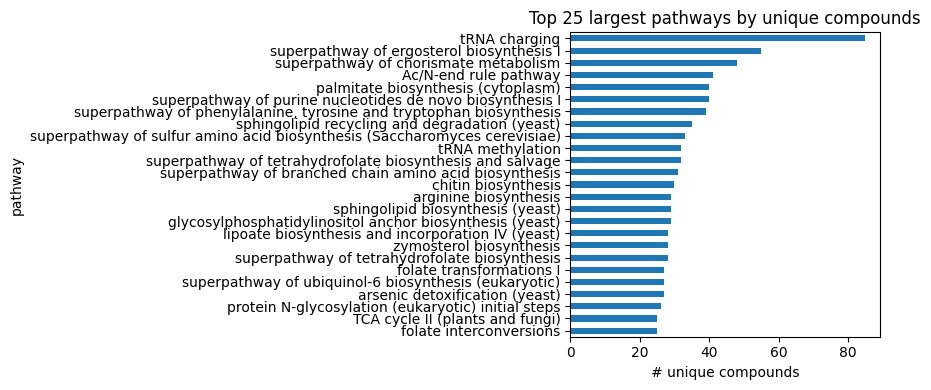

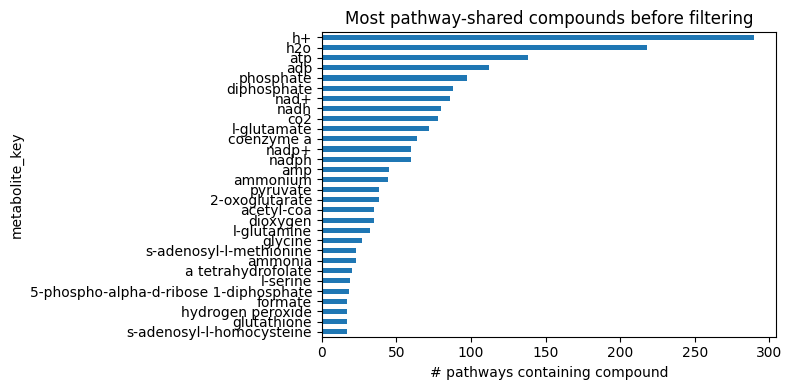

In [8]:

# ============================================================
# 5. Visualize pathway file composition
# ============================================================
pathway_sizes = pathway_membership.groupby("pathway")["metabolite_key"].nunique().sort_values(ascending=False)
plt.figure(figsize=(9,4))
pathway_sizes.head(25).sort_values().plot(kind="barh")
plt.title("Top 25 largest pathways by unique compounds")
plt.xlabel("# unique compounds")
plt.tight_layout()
plt.show()

compound_pathway_degree = pathway_membership.groupby("metabolite_key")["pathway"].nunique().sort_values(ascending=False)
plt.figure(figsize=(8,4))
compound_pathway_degree.head(30).sort_values().plot(kind="barh")
plt.title("Most pathway-shared compounds before filtering")
plt.xlabel("# pathways containing compound")
plt.tight_layout()
plt.show()

In [9]:

# ============================================================
# 6. Load compound→InChIKey and compound→SMILES maps
# ============================================================
def load_compound_maps(inchikey_file: Path, compound_file: Path):
    inchikey_map = {}
    local_smiles_map = {}
    source_map = {}

    def add_row(name, ikey=None, smiles=None, source=""):
        key = norm_name(name)
        if not key:
            return
        if ikey:
            ik = str(ikey).strip().replace("InChIKey=", "")
            if ik and key not in inchikey_map:
                inchikey_map[key] = ik
        if smiles:
            smi = str(smiles).strip()
            if smi and key not in local_smiles_map:
                local_smiles_map[key] = smi
                source_map[key] = source

    # compound-inchikey.txt can have Compound/InChI-Key/SMILES.
    df1 = pd.read_csv(inchikey_file, sep="\t", dtype=str).fillna("")
    for _, r in df1.iterrows():
        cols = {c.lower(): c for c in df1.columns}
        name = r[cols.get("compound", df1.columns[0])]
        ikey = r[cols.get("inchi-key", df1.columns[1] if len(df1.columns)>1 else df1.columns[0])] if len(df1.columns)>1 else ""
        smiles = r[cols.get("smiles", "")] if "smiles" in cols else ""
        add_row(name, ikey, smiles, source="compound-inchikey")

    # All-compounds file usually has Compound/InChI-Key.
    df2 = pd.read_csv(compound_file, sep="\t", dtype=str).fillna("")
    for _, r in df2.iterrows():
        cols = {c.lower(): c for c in df2.columns}
        name = r[cols.get("compound", df2.columns[0])]
        ikey = r[cols.get("inchi-key", df2.columns[1] if len(df2.columns)>1 else df2.columns[0])] if len(df2.columns)>1 else ""
        smiles = r[cols.get("smiles", "")] if "smiles" in cols else ""
        add_row(name, ikey, smiles, source="all-compounds")

    return inchikey_map, local_smiles_map, source_map, df1, df2

compound_inchikey_map, compound_local_smiles_map, compound_smiles_source_map, compound_inchikey_df, all_compounds_df = load_compound_maps(INCHIKEY_FILE, COMPOUND_FILE)
print("Compound InChIKeys:", len(compound_inchikey_map))
print("Local compound SMILES:", len(compound_local_smiles_map))
print("Raw compound-inchikey columns:", list(compound_inchikey_df.columns))
print("Raw all-compounds columns:", list(all_compounds_df.columns))

display(compound_inchikey_df.head(5))
display(all_compounds_df.head(5))

Compound InChIKeys: 1181
Local compound SMILES: 1232
Raw compound-inchikey columns: ['Compound', 'InChI-Key', 'SMILES']
Raw all-compounds columns: ['Compound', 'InChI-Key']


,Compound,InChI-Key,SMILES
0,FMNH2,InChIKey=YTNIXZGTHTVJBW-SCRDCRAPSA-L,CC1(\C(/C)=C/C2(/N(C[C@H](O)[C@H](O)[C@H](O)CO...
1,b-dglc-HEX-1:5|6:a,,
2,2-amino-4-methyl-5-hydroxyethylthiazole,InChIKey=XGHVUVFECVBQLK-UHFFFAOYSA-O,CC1(\NC(SC(/CCO)=1)=[NH2+])
3,(2E)-dodec-2-enoyl-CoA,InChIKey=IRFYVBULXZMEDE-DEEZISNZSA-J,CC(C)([C@@H](O)C(=O)NCCC(=O)NCCSC(=O)[R])COP(=...
4,an imino group,,[C-2]=[NH2+]


,Compound,InChI-Key
0,FMNH<SUB>2</SUB>,InChIKey=YTNIXZGTHTVJBW-SCRDCRAPSA-L
1,b-dglc-HEX-1:5|6:a,
2,2-amino-4-methyl-5-hydroxyethylthiazole,InChIKey=XGHVUVFECVBQLK-UHFFFAOYSA-O
3,(2<i>E</i>)-dodec-2-enoyl-CoA,InChIKey=IRFYVBULXZMEDE-DEEZISNZSA-J
4,an imino group,


Reaction-degree currency: 57
Explicit currency: 52
Pathway hubs: 65 threshold>= 9.0
Total currency set used for GNN removal: 75


,metabolite_key,reaction_degree
5,h+,741
1,h2o,416
20,atp,283
19,adp,212
36,phosphate,144
29,diphosphate,129
84,coenzyme a,121
32,nad+,116
30,nadh,111
8,co2,100


,metabolite_key,pathway_degree
899,h+,290
900,h2o,218
760,atp,138
575,adp,112
1026,phosphate,97
842,diphosphate,88
991,nad+,86
992,nadh,80
794,co2,78
934,l-glutamate,72


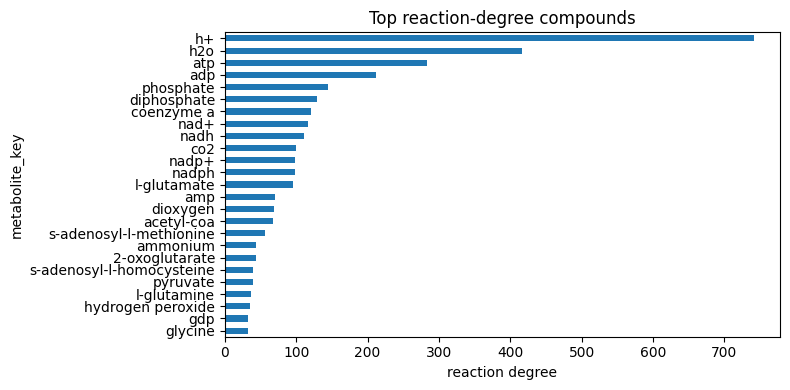

In [10]:

# ============================================================
# 7. Currency and hub metabolite detection
# ============================================================
EXPLICIT_CURRENCY = {
    "h+", "h2o", "water", "co2", "carbon dioxide", "o2", "dioxygen", "ammonia", "ammonium",
    "phosphate", "diphosphate", "pyrophosphate", "orthophosphate",
    "atp", "adp", "amp", "gtp", "gdp", "gmp", "utp", "udp", "ump", "ctp", "cdp", "cmp",
    "nad+", "nadh", "nadp+", "nadph", "fad", "fadh2", "fmn", "fmnh2",
    "coenzyme a", "coa", "acetyl-coa", "malonyl-coa",
    "a reduced thioredoxin", "an oxidized thioredoxin", "reduced thioredoxin", "oxidized thioredoxin",
    "s-adenosyl-l-methionine", "s-adenosyl-l-homocysteine", "a tetrahydrofolate", "an n10-formyltetrahydrofolate",
    "l-glutamate", "l-glutamine", "glycine", "l-aspartate", "pyruvate", "2-oxoglutarate", "fumarate",
}

def detect_currency_by_reaction_degree(reaction_df: pd.DataFrame, percentile=95.0):
    counts = Counter()
    for comps in reaction_df["compounds"]:
        for c in set(comps):
            counts[norm_name(c)] += 1
    if not counts:
        return set(), pd.DataFrame()
    vals = np.array(list(counts.values()), dtype=float)
    threshold = np.percentile(vals, percentile)
    currency = {k for k, v in counts.items() if v > threshold}
    stat = pd.DataFrame({"metabolite_key": list(counts.keys()), "reaction_degree": list(counts.values())}).sort_values("reaction_degree", ascending=False)
    return currency, stat

def detect_pathway_hubs(pathway_membership: pd.DataFrame, percentile=95.0, min_degree=6):
    deg = pathway_membership.groupby("metabolite_key")["pathway"].nunique()
    threshold = max(min_degree, np.percentile(deg.values, percentile)) if len(deg) else min_degree
    hubs = set(deg[deg >= threshold].index)
    stat = deg.reset_index(name="pathway_degree").sort_values("pathway_degree", ascending=False)
    return hubs, stat, threshold

reaction_currency, reaction_degree_df = detect_currency_by_reaction_degree(reaction_df, CURRENCY_PCT)
pathway_hubs, pathway_degree_df, pathway_hub_threshold = detect_pathway_hubs(pathway_membership, 95.0, min_degree=6)
explicit_currency_norm = {norm_name(x) for x in EXPLICIT_CURRENCY}
all_currency = reaction_currency | explicit_currency_norm

print("Reaction-degree currency:", len(reaction_currency))
print("Explicit currency:", len(explicit_currency_norm))
print("Pathway hubs:", len(pathway_hubs), "threshold>=", pathway_hub_threshold)
print("Total currency set used for GNN removal:", len(all_currency))

display(reaction_degree_df.head(20))
display(pathway_degree_df.head(20))

plt.figure(figsize=(8,4))
reaction_degree_df.head(25).sort_values("reaction_degree").plot(x="metabolite_key", y="reaction_degree", kind="barh", legend=False, ax=plt.gca())
plt.title("Top reaction-degree compounds")
plt.xlabel("reaction degree")
plt.tight_layout()
plt.show()

Resolving metabolite SMILES:   0%|          | 0/1133 [00:00<?, ?it/s]

All pathway compounds: 1133
After currency removal + SMILES availability: 1027


,smiles_source,count
0,local_compound_file,629
1,pathway_file,464
2,missing,40


,metabolite_name,metabolite_key,smiles,smiles_source,inchikey
0,"(1,4-alpha-D-glucosyl)n-glucosyl glucogenin","(1,4-alpha-d-glucosyl)n-glucosyl glucogenin",C(O)[C@H]3(O[C@H](O[C@H]2([C@H](O)[C@@H](O)[C@...,pathway_file,
1,"(1R,2S)-homoisocitrate","(1r,2s)-homoisocitrate",C([R])(=O)[O-],local_compound_file,OEJZZCGRGVFWHK-WVZVXSGGSA-K
2,"(1S,2R)-1-C-(indol-3-yl)glycerol 3-phosphate","(1s,2r)-1-c-(indol-3-yl)glycerol 3-phosphate",C1(/NC2(/C=C\C=C/C(/C(/[C@@H]([C@@H](COP([O-])...,local_compound_file,NQEQTYPJSIEPHW-MNOVXSKESA-L
3,(2E)-2-ethylidene-4-hydroxy-5-methyl-3(2H)-fur...,(2e)-2-ethylidene-4-hydroxy-5-methyl-3(2h)-fur...,C/C=C1(C(=O)C(/O)=C(C)\O1),local_compound_file,CWXWDRXNERDGHE-HWKANZROSA-N
4,(2E)-dec-2-enoyl-CoA,(2e)-dec-2-enoyl-coa,CC(C)([C@@H](O)C(=O)NCCC(=O)NCCSC(=O)[R])COP(=...,local_compound_file,MGNBGCRQQFMNBM-YJHHLLFWSA-J
5,(2E)-dodec-2-enoyl-CoA,(2e)-dodec-2-enoyl-coa,CC(C)([C@@H](O)C(=O)NCCC(=O)NCCSC(=O)[R])COP(=...,local_compound_file,IRFYVBULXZMEDE-DEEZISNZSA-J
6,(2E)-icos-2-enoyl-CoA,(2e)-icos-2-enoyl-coa,CC(C)([C@@H](O)C(=O)NCCC(=O)NCCSC(=O)[R])COP(=...,local_compound_file,ROOFWBIMBMJYGA-DSAUMYHJSA-J
7,(2E)-tetradec-2-enoyl-CoA,(2e)-tetradec-2-enoyl-coa,CC(C)([C@@H](O)C(=O)NCCC(=O)NCCSC(=O)[R])COP(=...,local_compound_file,MBCVYCOKMMMWLX-YYMFEJJQSA-J
8,(2E)-undec-2-enoyl-CoA,(2e)-undec-2-enoyl-coa,CCCCCCCC/C=C/C(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C...,local_compound_file,CAVMKINPGRCURL-PHHHIDLGSA-J
9,"(2E, 4E)-undeca-2,4-dienoyl-CoA","(2e, 4e)-undeca-2,4-dienoyl-coa",CCCCCC/C=C/C=C/C(=O)SCCNC(=O)CCNC(=O)[C@H](O)C...,local_compound_file,SZKPLUULGGERFD-MSNZEOPQSA-J


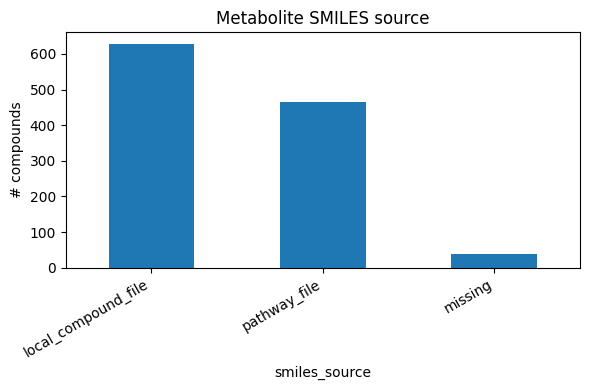

In [11]:

# ============================================================
# 8. Resolve metabolite SMILES from local maps + pathway SMILES + optional PubChem
# ============================================================
def fetch_smiles_by_inchikey(inchikey: str, timeout=10):
    if not inchikey:
        return None
    url = f"https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound/inchikey/{quote(inchikey)}/property/SMILES/JSON"
    try:
        r = requests.get(url, timeout=timeout)
        if r.status_code == 200:
            props = r.json().get("PropertyTable", {}).get("Properties", [])
            if props:
                return props[0].get("SMILES")
    except Exception:
        return None
    return None

def resolve_metabolite_smiles(pathway_membership, pathway_smiles_df, local_smiles_map, inchikey_map, mode="local_first", fetch_missing=False):
    names = (pathway_membership[["metabolite_name", "metabolite_key"]]
             .drop_duplicates("metabolite_key")
             .sort_values("metabolite_name")
             .reset_index(drop=True))
    pathway_smi_map = dict(zip(pathway_smiles_df["metabolite_key"], pathway_smiles_df["pathway_smiles"])) if len(pathway_smiles_df) else {}
    rows = []
    for _, r in tqdm(names.iterrows(), total=len(names), desc="Resolving metabolite SMILES"):
        key = r["metabolite_key"]
        smi = None
        source = None
        if mode == "local_first":
            if key in local_smiles_map:
                smi, source = local_smiles_map[key], "local_compound_file"
            elif key in pathway_smi_map:
                smi, source = pathway_smi_map[key], "pathway_file"
        else:
            if key in pathway_smi_map:
                smi, source = pathway_smi_map[key], "pathway_file"
            elif key in local_smiles_map:
                smi, source = local_smiles_map[key], "local_compound_file"
        if (not smi) and fetch_missing and key in inchikey_map:
            smi = fetch_smiles_by_inchikey(inchikey_map[key])
            source = "pubchem_inchikey" if smi else None
            time.sleep(0.1)
        rows.append({
            "metabolite_name": r["metabolite_name"],
            "metabolite_key": key,
            "smiles": smi,
            "smiles_source": source or "missing",
            "inchikey": inchikey_map.get(key, ""),
        })
    return pd.DataFrame(rows)

metabolites_all_df = resolve_metabolite_smiles(
    pathway_membership, pathway_smiles_df, compound_local_smiles_map, compound_inchikey_map,
    mode=METABOLITE_SMILES_MODE, fetch_missing=FETCH_MISSING_METABOLITE_SMILES,
)

# Exclude currency from metabolite node set before GNN.
metabolites_df = metabolites_all_df[~metabolites_all_df["metabolite_key"].isin(all_currency)].copy()
metabolites_df = metabolites_df.dropna(subset=["smiles"]).query("smiles != ''").reset_index(drop=True)

print("All pathway compounds:", len(metabolites_all_df))
print("After currency removal + SMILES availability:", len(metabolites_df))
display(metabolites_all_df["smiles_source"].value_counts().reset_index(name="count").rename(columns={"index":"source"}))
display(metabolites_df.head(10))

plt.figure(figsize=(6,4))
metabolites_all_df["smiles_source"].value_counts().plot(kind="bar")
plt.title("Metabolite SMILES source")
plt.ylabel("# compounds")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

[12:05:29] SMILES Parse Error: syntax error while parsing: C(O)[C@H]3(O[C@H](O[C@H]2([C@H](O)[C@@H](O)[C@@H](OC1(\C=C/C(\C[C@@H](C([a
[12:05:29] SMILES Parse Error: check for mistakes around position 74:
[12:05:29] (\C=C/C(\C[C@@H](C([a
[12:05:29] ~~~~~~~~~~~~~~~~~~~~^
[12:05:29] SMILES Parse Error: extra open parentheses while parsing: C(O)[C@H]3(O[C@H](O[C@H]2([C@H](O)[C@@H](O)[C@@H](OC1(\C=C/C(\C[C@@H](C([a
[12:05:29] SMILES Parse Error: check for mistakes around position 11:
[12:05:29] C(O)[C@H]3(O[C@H](O[C@H]2([C@H](O)[C@@H](
[12:05:29] ~~~~~~~~~~^
[12:05:29] SMILES Parse Error: extra open parentheses while parsing: C(O)[C@H]3(O[C@H](O[C@H]2([C@H](O)[C@@H](O)[C@@H](OC1(\C=C/C(\C[C@@H](C([a
[12:05:29] SMILES Parse Error: check for mistakes around position 18:
[12:05:29] C(O)[C@H]3(O[C@H](O[C@H]2([C@H](O)[C@@H](
[12:05:29] ~~~~~~~~~~~~~~~~~^
[12:05:29] SMILES Parse Error: extra open parentheses while parsing: C(O)[C@H]3(O[C@H](O[C@H]2([C@H](O)[C@@H](O)[C@@H](OC1(\C=C/C(\C[C@@H](C([a

Metabolites with valid RDKit fingerprint: 479


[12:05:29] WARNING: not removing hydrogen atom without neighbors
[12:05:29] WARNING: not removing hydrogen atom without neighbors
[12:05:29] WARNING: not removing hydrogen atom without neighbors
[12:05:29] WARNING: not removing hydrogen atom without neighbors
[12:05:29] WARNING: not removing hydrogen atom without neighbors
[12:05:29] WARNING: not removing hydrogen atom without neighbors


,metabolite_name,smiles_source,mol_wt,heavy_atoms,hetero_ratio
0,"(1S,2R)-1-C-(indol-3-yl)glycerol 3-phosphate",local_compound_file,285.192,19.0,0.421053
1,(2E)-2-ethylidene-4-hydroxy-5-methyl-3(2H)-fur...,local_compound_file,140.138,10.0,0.300000
2,(2E)-undec-2-enoyl-CoA,local_compound_file,929.773,60.0,0.466667
3,"(2E, 4E)-undeca-2,4-dienoyl-CoA",local_compound_file,927.757,60.0,0.466667
4,"(2E,4E)-tetradeca-2,4-dienoyl-CoA",local_compound_file,969.838,63.0,0.444444
5,"(2E,5E)-dodeca-2,5-dienoyl-CoA",local_compound_file,941.784,61.0,0.459016
6,"(2E,6E)-farnesol",local_compound_file,222.372,16.0,0.062500
7,"(2E,6E)-farnesyl diphosphate",local_compound_file,379.306,24.0,0.375000
8,"(2R)-2,3-dihydroxy-3-methylbutanoate",local_compound_file,133.123,9.0,0.444444
9,"(2R,3S)-3-isopropylmalate",local_compound_file,174.152,12.0,0.416667


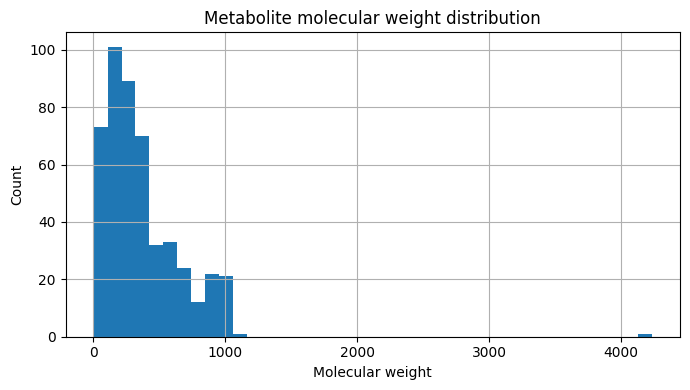

In [12]:

# ============================================================
# 9. Morgan fingerprints and metabolite quality checks
# ============================================================
_morgan_gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)

def smiles_to_mol(smiles: str):
    if pd.isna(smiles) or not str(smiles).strip():
        return None
    try:
        return Chem.MolFromSmiles(str(smiles))
    except Exception:
        return None

def smiles_to_fp(smiles: str):
    mol = smiles_to_mol(smiles)
    if mol is None:
        return None
    try:
        return _morgan_gen.GetFingerprint(mol)
    except Exception:
        return None

def fp_to_tensor(fp) -> torch.Tensor:
    arr = np.zeros((fp.GetNumBits(),), dtype=np.int8)
    DataStructs.ConvertToNumpyArray(fp, arr)
    return torch.tensor(arr, dtype=torch.float32)

def calc_mol_props(smiles: str):
    mol = smiles_to_mol(smiles)
    if mol is None:
        return pd.Series({"mol_wt": np.nan, "heavy_atoms": np.nan, "hetero_ratio": np.nan})
    heavy = mol.GetNumHeavyAtoms()
    hetero = sum(1 for a in mol.GetAtoms() if a.GetAtomicNum() not in (1, 6))
    return pd.Series({"mol_wt": Descriptors.MolWt(mol), "heavy_atoms": heavy, "hetero_ratio": hetero / max(1, heavy)})

metabolites_df["fp"] = metabolites_df["smiles"].apply(smiles_to_fp)
metabolites_df = metabolites_df.dropna(subset=["fp"]).reset_index(drop=True)
metabolites_df = pd.concat([metabolites_df, metabolites_df["smiles"].apply(calc_mol_props)], axis=1)

print("Metabolites with valid RDKit fingerprint:", len(metabolites_df))
display(metabolites_df[["metabolite_name", "smiles_source", "mol_wt", "heavy_atoms", "hetero_ratio"]].head(10))

plt.figure(figsize=(7,4))
metabolites_df["mol_wt"].dropna().hist(bins=40)
plt.title("Metabolite molecular weight distribution")
plt.xlabel("Molecular weight")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

Pathway graph compounds: 1142
Pathway graph undirected edges: 1190


Computing RWPE:   0%|          | 0/20 [00:00<?, ?it/s]

RWPE lookup: 431/479 matched


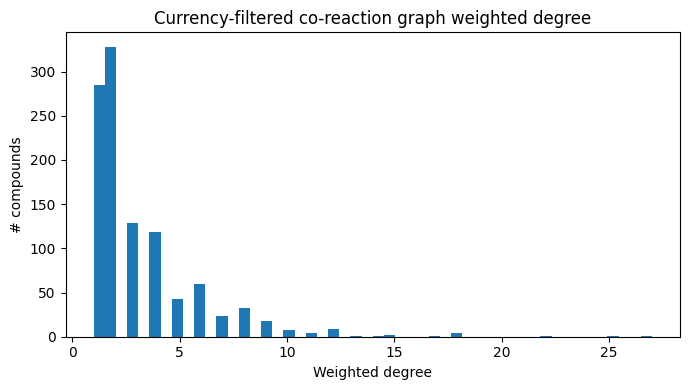

In [13]:

# ============================================================
# 10. Build currency-filtered co-reaction graph and RWPE
# ============================================================
def build_pathway_graph_from_reactions(reaction_df: pd.DataFrame, currency_set: set):
    comp2idx = {}
    edge_freq = defaultdict(int)
    for _, row in reaction_df.iterrows():
        lefts = [norm_name(x) for x in row["lefts"]]
        rights = [norm_name(x) for x in row["rights"]]
        for c in lefts + rights:
            if c and c not in comp2idx:
                comp2idx[c] = len(comp2idx)
        for l in lefts:
            if not l or l in currency_set:
                continue
            for r in rights:
                if not r or r in currency_set or l == r:
                    continue
                i, j = comp2idx[l], comp2idx[r]
                edge_freq[(i, j)] += 1
                edge_freq[(j, i)] += 1
    N = len(comp2idx)
    if not edge_freq:
        return comp2idx, sp.csr_matrix((N, N), dtype=np.float32)
    rows = [k[0] for k in edge_freq]
    cols = [k[1] for k in edge_freq]
    vals = np.array([edge_freq[k] for k in edge_freq], dtype=np.float32)
    A = sp.csr_matrix((vals, (rows, cols)), shape=(N, N), dtype=np.float32)
    return comp2idx, A

def compute_rwpe_matrix(A: sp.spmatrix, K: int) -> np.ndarray:
    N = A.shape[0]
    degree = np.array(A.sum(axis=1), dtype=np.float64).flatten()
    degree[degree == 0] = 1.0
    T = (sp.diags(1.0 / degree) @ A).astype(np.float32)
    rwpe = np.zeros((N, K), dtype=np.float32)
    T_k = T.copy()
    for k in tqdm(range(K), desc="Computing RWPE"):
        rwpe[:, k] = np.array(T_k.diagonal()).flatten()
        if k < K - 1:
            T_k = T_k @ T
    return rwpe

def get_metabolite_rwpe(metabolite_keys, comp2idx, rwpe_full, K):
    out = np.zeros((len(metabolite_keys), K), dtype=np.float32)
    found = 0
    for i, key in enumerate(metabolite_keys):
        key = COMPOUND_SYNONYMS.get(key, key)
        if key in comp2idx:
            out[i] = rwpe_full[comp2idx[key]]
            found += 1
    print(f"RWPE lookup: {found}/{len(metabolite_keys)} matched")
    return out

comp2idx, A_pathway = build_pathway_graph_from_reactions(reaction_df, all_currency)
print("Pathway graph compounds:", len(comp2idx))
print("Pathway graph undirected edges:", A_pathway.nnz // 2)
rwpe_full = compute_rwpe_matrix(A_pathway, WALK_LENGTH) if A_pathway.shape[0] else np.zeros((0, WALK_LENGTH), dtype=np.float32)
rwpe_met = get_metabolite_rwpe(metabolites_df["metabolite_key"].tolist(), comp2idx, rwpe_full, WALK_LENGTH)

# Visualize graph degree distribution.
deg = np.array(A_pathway.sum(axis=1)).flatten() if A_pathway.shape[0] else np.array([])
plt.figure(figsize=(7,4))
if len(deg):
    plt.hist(deg[deg > 0], bins=50)
plt.title("Currency-filtered co-reaction graph weighted degree")
plt.xlabel("Weighted degree")
plt.ylabel("# compounds")
plt.tight_layout()
plt.show()

In [14]:

# ============================================================
# 11. Load drug-target and target-disease edges + fetch drug SMILES
# ============================================================
def load_drug_target_edges(path: Path):
    raw = pd.read_csv(path)
    colmap = {c.lower(): c for c in raw.columns}
    drug_col = colmap.get("drug_id") or colmap.get("drug_name") or raw.columns[0]
    target_col = colmap.get("target_symbol") or colmap.get("target_id") or raw.columns[1]
    conf_col = colmap.get("confidence") or colmap.get("score")
    out = raw[[drug_col, target_col] + ([conf_col] if conf_col else [])].copy()
    out = out.rename(columns={drug_col: "drug_name", target_col: "target_id"})
    out["drug_name"] = out["drug_name"].astype(str)
    out["target_id"] = out["target_id"].astype(str)
    out["confidence"] = out[conf_col].astype(float) if conf_col else 1.0
    return out[["drug_name", "target_id", "confidence"]]

def load_target_disease_edges(path: Path):
    raw = pd.read_csv(path)
    colmap = {c.lower(): c for c in raw.columns}
    target_col = colmap.get("target_symbol") or colmap.get("target_id") or raw.columns[0]
    score_col = colmap.get("association_score") or colmap.get("score")
    disease_col = colmap.get("disease_id")
    disease_name_col = colmap.get("disease_name")
    out = pd.DataFrame({
        "target_id": raw[target_col].astype(str),
        "association_score": raw[score_col].astype(float) if score_col else 1.0,
        "disease_id": raw[disease_col].astype(str) if disease_col else "ALOPECIA",
        "disease_name": raw[disease_name_col].astype(str) if disease_name_col else "Alopecia",
    })
    out["disease_id"] = "ALOPECIA"
    out["disease_name"] = "Alopecia"
    return out

def fetch_single_drug_smiles(drug_name: str):
    # ChEMBL first for CHEMBL identifiers, then PubChem name lookup.
    name = str(drug_name)
    if name.upper().startswith("CHEMBL"):
        url = f"https://www.ebi.ac.uk/chembl/api/data/molecule/{name.upper()}.json"
        try:
            r = requests.get(url, timeout=10)
            if r.status_code == 200:
                structs = r.json().get("molecule_structures") or {}
                smi = structs.get("canonical_smiles") or structs.get("standard_smiles")
                if smi:
                    return name, smi, "ChEMBL"
        except Exception:
            pass
    safe = quote(name)
    url = f"https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound/name/{safe}/property/SMILES/JSON"
    try:
        r = requests.get(url, timeout=10)
        if r.status_code == 200:
            props = r.json().get("PropertyTable", {}).get("Properties", [])
            if props:
                smi = props[0].get("SMILES")
                if smi:
                    return name, smi, "PubChem"
    except Exception:
        pass
    return name, None, "missing"

def fetch_drug_smiles(drug_names, max_workers=5):
    from concurrent.futures import ThreadPoolExecutor, as_completed
    unique = list(dict.fromkeys([str(x) for x in drug_names]))
    rows = []
    if not FETCH_DRUG_SMILES:
        return pd.DataFrame({"drug_name": unique, "smiles": [None]*len(unique), "drug_smiles_source": ["disabled"]*len(unique)})
    with ThreadPoolExecutor(max_workers=max_workers) as ex:
        futs = [ex.submit(fetch_single_drug_smiles, n) for n in unique]
        for fut in tqdm(as_completed(futs), total=len(futs), desc="Fetching drug SMILES"):
            name, smi, src = fut.result()
            rows.append({"drug_name": name, "smiles": smi, "drug_smiles_source": src})
            time.sleep(0.05)
    return pd.DataFrame(rows)

drug_target_edges = load_drug_target_edges(DRUG_TARGET_FILE)
target_disease_edges = load_target_disease_edges(TARGET_DISEASE_FILE)
drugs_df = pd.DataFrame({"drug_name": sorted(drug_target_edges["drug_name"].unique())})
targets_df = pd.DataFrame({"target_id": sorted(set(drug_target_edges["target_id"]) | set(target_disease_edges["target_id"]))})

drug_smiles_df = fetch_drug_smiles(drugs_df["drug_name"], MAX_WORKERS)
drugs_df = drugs_df.merge(drug_smiles_df, on="drug_name", how="left")
drugs_df["fp"] = drugs_df["smiles"].apply(smiles_to_fp)
drugs_df = drugs_df.dropna(subset=["fp"]).reset_index(drop=True)
drug_target_edges = drug_target_edges[drug_target_edges["drug_name"].isin(drugs_df["drug_name"])].reset_index(drop=True)

print("Drug-target rows:", len(drug_target_edges))
print("Drugs with valid SMILES/fp:", len(drugs_df))
print("Targets:", len(targets_df))
print("Target-disease rows:", len(target_disease_edges))
display(drugs_df["drug_smiles_source"].value_counts().reset_index(name="count"))
display(drug_target_edges.head())

Fetching drug SMILES:   0%|          | 0/257 [00:00<?, ?it/s]

Drug-target rows: 1286
Drugs with valid SMILES/fp: 257
Targets: 50
Target-disease rows: 50


,drug_smiles_source,count
0,ChEMBL,257


,drug_name,target_id,confidence
0,CHEMBL2051982,DKK2,0.95
1,CHEMBL2442258,DKK2,0.95
2,CHEMBL501355,DKK2,0.95
3,CHEMBL2051982,TYK2,0.95
4,CHEMBL2051761,TYK2,0.95


Metabolite→drug Tanimoto:   0%|          | 0/479 [00:00<?, ?it/s]

Metabolite-drug Tanimoto edges: 2395


,metabolite_name,metabolite_key,drug_name,tanimoto
710,4-hydroxybenzaldehyde,4-hydroxybenzaldehyde,CHEMBL165,0.458333
2025,myo-inositol,myo-inositol,CHEMBL174067,0.454545
505,2-phenylethanol,2-phenylethanol,CHEMBL5401203,0.428571
1790,"ergosta-5,7,22,24(28)-tetraen-3beta-ol","ergosta-5,7,22,24(28)-tetraen-3beta-ol",CHEMBL2111947,0.338235
1638,beta-D-mannopyranose,beta-d-mannopyranose,CHEMBL2115215,0.333333
1636,beta-D-mannopyranose,beta-d-mannopyranose,CHEMBL501355,0.333333
1635,beta-D-mannopyranose,beta-d-mannopyranose,CHEMBL174067,0.333333
1633,beta-D-glucopyranose,beta-d-glucopyranose,CHEMBL2115215,0.333333
1634,beta-D-glucopyranose,beta-d-glucopyranose,CHEMBL2114210,0.333333
1632,beta-D-glucopyranose,beta-d-glucopyranose,CHEMBL2093897,0.333333


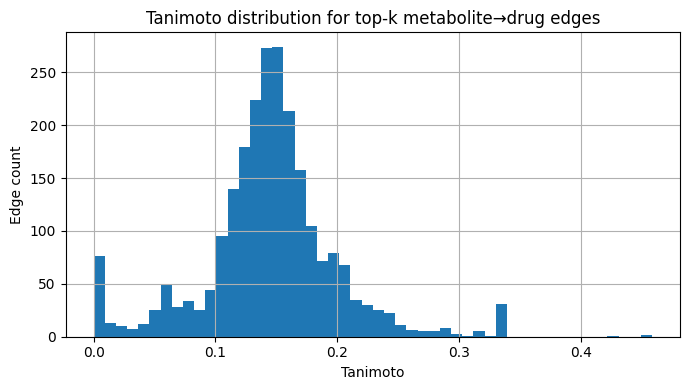

In [15]:

# ============================================================
# 12. Build metabolite→drug Tanimoto edges
# ============================================================
drug_names = drugs_df["drug_name"].tolist()
drug_fps = drugs_df["fp"].tolist()
rows = []
for met in tqdm(metabolites_df.itertuples(index=False), total=len(metabolites_df), desc="Metabolite→drug Tanimoto"):
    sims = DataStructs.BulkTanimotoSimilarity(met.fp, drug_fps)
    top_idx = np.argsort(sims)[::-1][:TOP_K_TANIMOTO]
    for j in top_idx:
        rows.append({
            "metabolite_name": met.metabolite_name,
            "metabolite_key": met.metabolite_key,
            "drug_name": drug_names[j],
            "tanimoto": float(sims[j]),
        })
metabolite_drug_edges = pd.DataFrame(rows)
print("Metabolite-drug Tanimoto edges:", len(metabolite_drug_edges))
display(metabolite_drug_edges.sort_values("tanimoto", ascending=False).head(20))

plt.figure(figsize=(7,4))
metabolite_drug_edges["tanimoto"].hist(bins=50)
plt.title("Tanimoto distribution for top-k metabolite→drug edges")
plt.xlabel("Tanimoto")
plt.ylabel("Edge count")
plt.tight_layout()
plt.show()

In [16]:

# ============================================================
# 13. Build PyG HeteroData
# ============================================================
def make_mapping(values):
    vals = sorted(pd.Series(values).dropna().astype(str).unique().tolist())
    id2idx = {v: i for i, v in enumerate(vals)}
    idx2id = {i: v for v, i in id2idx.items()}
    return id2idx, idx2id

def build_edge_index(df, src_col, dst_col, src_map, dst_map):
    src, dst = [], []
    for _, r in df.iterrows():
        s, d = str(r[src_col]), str(r[dst_col])
        if s in src_map and d in dst_map:
            src.append(src_map[s])
            dst.append(dst_map[d])
    if not src:
        return torch.empty((2,0), dtype=torch.long)
    return torch.tensor([src, dst], dtype=torch.long)

met2idx, idx2met = make_mapping(metabolites_df["metabolite_name"])
drug2idx, idx2drug = make_mapping(drugs_df["drug_name"])
target2idx, idx2target = make_mapping(targets_df["target_id"])

data = HeteroData()
data["metabolite"].num_nodes = len(met2idx)
data["drug"].num_nodes = len(drug2idx)
data["target"].num_nodes = len(target2idx)

md_edge = build_edge_index(metabolite_drug_edges, "metabolite_name", "drug_name", met2idx, drug2idx)
dt_edge = build_edge_index(drug_target_edges, "drug_name", "target_id", drug2idx, target2idx)

data["metabolite", "similar_to", "drug"].edge_index = md_edge
data["drug", "rev_similar_to", "metabolite"].edge_index = md_edge.flip(0)
data["drug", "inhibits", "target"].edge_index = dt_edge
data["target", "rev_inhibits", "drug"].edge_index = dt_edge.flip(0)

# Node features
met_fps = torch.stack([fp_to_tensor(fp) for fp in metabolites_df["fp"]])
met_rwpe = torch.tensor(rwpe_met, dtype=torch.float32)
data["metabolite"].x = torch.cat([met_fps, met_rwpe], dim=-1)
data["drug"].x = torch.stack([fp_to_tensor(fp) for fp in drugs_df["fp"]])
data["target"].x = torch.ones((data["target"].num_nodes, 1), dtype=torch.float32)

print(data)
print("metabolite.x:", tuple(data["metabolite"].x.shape))
print("drug.x:", tuple(data["drug"].x.shape))
print("target.x:", tuple(data["target"].x.shape))

HeteroData(
  metabolite={
    num_nodes=479,
    x=[479, 2068],
  },
  drug={
    num_nodes=257,
    x=[257, 2048],
  },
  target={
    num_nodes=50,
    x=[50, 1],
  },
  (metabolite, similar_to, drug)={ edge_index=[2, 2395] },
  (drug, rev_similar_to, metabolite)={ edge_index=[2, 2395] },
  (drug, inhibits, target)={ edge_index=[2, 1286] },
  (target, rev_inhibits, drug)={ edge_index=[2, 1286] }
)
metabolite.x: (479, 2068)
drug.x: (257, 2048)
target.x: (50, 1)


DEVICE: cuda
EPOCHS: 30
BATCH_SIZE: 128
valid_train_etypes: [('metabolite', 'similar_to', 'drug'), ('drug', 'inhibits', 'target')]
valid_val_etypes: [('metabolite', 'similar_to', 'drug'), ('drug', 'inhibits', 'target')]
valid_test_etypes: [('metabolite', 'similar_to', 'drug'), ('drug', 'inhibits', 'target')]
Loaders -- train:2 val:2 test:2
in_channels_dict: {'metabolite': 2068, 'drug': 2048, 'target': 1}
Model and optimizer ready.

Start v5-style LinkNeighborLoader training
Epoch 001 | loss=0.4307 | val_AUC=0.8552 | val_AP=0.8429 | val_F1=0.7857
  similar_to | AUC=0.7962 AP=0.7916 F1=0.7301
  inhibits | AUC=0.9143 AP=0.8942 F1=0.8414
Epoch 002 | loss=0.4261 | val_AUC=0.9339 | val_AP=0.9377 | val_F1=0.8500
  similar_to | AUC=0.9069 AP=0.9091 F1=0.8376
  inhibits | AUC=0.9609 AP=0.9664 F1=0.8625
Epoch 003 | loss=0.2847 | val_AUC=0.9464 | val_AP=0.9439 | val_F1=0.8701
  similar_to | AUC=0.9224 AP=0.9192 F1=0.8491
  inhibits | AUC=0.9704 AP=0.9686 F1=0.8911
Epoch 004 | loss=0.1718 | val_AU

,epoch,train_loss,mean_val_AUC,mean_val_AP,mean_val_F1
0,1,0.430680,0.855230,0.842915,0.785740
1,2,0.426120,0.933891,0.937748,0.850048
2,3,0.284748,0.946372,0.943868,0.870063
3,4,0.171792,0.942445,0.941135,0.860318
4,5,0.109782,0.952028,0.941573,0.889984
5,6,0.076342,0.950361,0.935827,0.892675
6,7,0.056272,0.960122,0.955322,0.895052
7,8,0.027424,0.953474,0.948332,0.891397
8,9,0.042532,0.951873,0.939393,0.886726
9,10,0.029157,0.952431,0.944040,0.889938


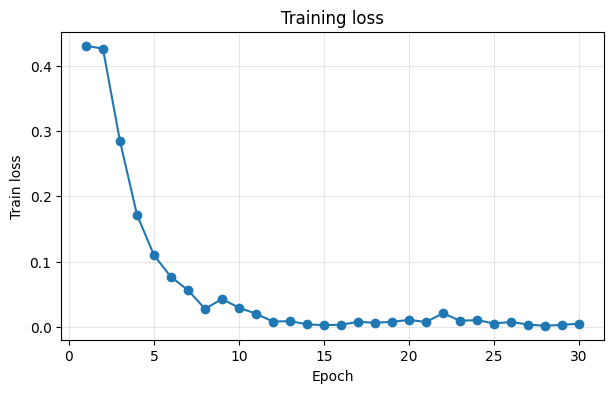

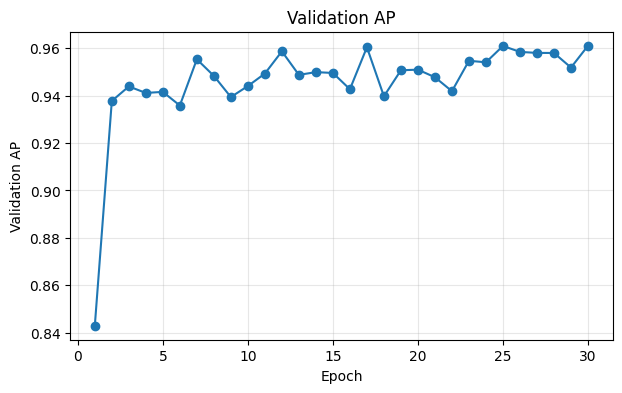


Test results


,edge_type,AUC,AP,F1
0,metabolite-similar_to-drug,0.938969,0.931906,0.870311
1,drug-inhibits-target,0.982256,0.977102,0.937500


In [22]:
# ============================================================
# Cell 14-15. v5 original-style model / split / loader / training
# 실행 위치: HeteroData `data`가 만들어진 직후
# ============================================================

import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict

import torch
import torch.nn as nn
import torch.nn.functional as F

from sklearn.metrics import roc_auc_score, average_precision_score, f1_score
from torch_geometric.nn import HANConv
from torch_geometric.transforms import RandomLinkSplit
from torch_geometric.loader import LinkNeighborLoader


# ------------------------------------------------------------
# 1. Config
# ------------------------------------------------------------
DEVICE = globals().get("DEVICE", torch.device("cuda" if torch.cuda.is_available() else "cpu"))

EPOCHS = globals().get("EPOCHS", 10)        # 먼저 10으로 확인, 잘 되면 30
BATCH_SIZE = globals().get("BATCH_SIZE", 512)
HIDDEN = globals().get("HIDDEN", 256)
HEADS = globals().get("HEADS", 4)
DROPOUT = globals().get("DROPOUT", 0.1)
LR = globals().get("LR", 1e-3)

TASK_EDGE_TYPES = [
    ("metabolite", "similar_to", "drug"),
    ("drug", "inhibits", "target"),
]

REV_EDGE_TYPES = [
    ("drug", "rev_similar_to", "metabolite"),
    ("target", "rev_inhibits", "drug"),
]

print("DEVICE:", DEVICE)
print("EPOCHS:", EPOCHS)
print("BATCH_SIZE:", BATCH_SIZE)


# ------------------------------------------------------------
# 2. Model definition
# ------------------------------------------------------------
class InductiveHANLinkPredictor(nn.Module):
    def __init__(
        self,
        metadata,
        in_channels_dict,
        hidden_channels=256,
        out_channels=256,
        heads=4,
        dropout=0.1,
    ):
        super().__init__()

        self.node_proj = nn.ModuleDict({
            nt: nn.Linear(in_dim, hidden_channels)
            for nt, in_dim in in_channels_dict.items()
        })

        self.conv1 = HANConv(
            hidden_channels,
            hidden_channels,
            metadata=metadata,
            heads=heads,
            dropout=dropout,
        )

        self.conv2 = HANConv(
            hidden_channels,
            out_channels,
            metadata=metadata,
            heads=heads,
            dropout=dropout,
        )

    def forward(self, data):
        x_proj = {
            nt: self.node_proj[nt](x)
            for nt, x in data.x_dict.items()
        }

        out1 = self.conv1(x_proj, data.edge_index_dict)

        x_dict = {}
        for nt in x_proj:
            if out1.get(nt) is not None:
                x_dict[nt] = F.elu(out1[nt] + x_proj[nt])
            else:
                x_dict[nt] = F.elu(x_proj[nt])

        out2 = self.conv2(x_dict, data.edge_index_dict)

        final_dict = {}
        for nt in x_dict:
            if out2.get(nt) is not None:
                final_dict[nt] = out2[nt] + x_dict[nt]
            else:
                final_dict[nt] = x_dict[nt]

        return final_dict

    def decode(self, z_dict, edge_label_index, src_type, dst_type):
        src_z = z_dict[src_type][edge_label_index[0]]
        dst_z = z_dict[dst_type][edge_label_index[1]]
        return (src_z * dst_z).sum(dim=-1)


# ------------------------------------------------------------
# 3. Loss / evaluation
# ------------------------------------------------------------
def compute_loss(model, batch, task_edge_types, device):
    z_dict = model(batch)
    losses = []

    for etype in task_edge_types:
        if etype not in batch.edge_types:
            continue

        if not hasattr(batch[etype], "edge_label_index"):
            continue

        if not hasattr(batch[etype], "edge_label"):
            continue

        src_type, _, dst_type = etype

        logits = model.decode(
            z_dict,
            batch[etype].edge_label_index,
            src_type,
            dst_type,
        )

        labels = batch[etype].edge_label.float()
        loss = F.binary_cross_entropy_with_logits(logits, labels)
        losses.append(loss)

    if len(losses) == 0:
        return torch.tensor(0.0, device=device, requires_grad=True)

    return sum(losses) / len(losses)


@torch.no_grad()
def evaluate_auc_ap(model, loaders, edge_types, device):
    model.eval()

    y_true_d = defaultdict(list)
    y_prob_d = defaultdict(list)

    for loader, etype in zip(loaders, edge_types):
        for batch in loader:
            batch = batch.to(device)

            if etype not in batch.edge_types:
                continue

            if not hasattr(batch[etype], "edge_label_index"):
                continue

            if not hasattr(batch[etype], "edge_label"):
                continue

            z_dict = model(batch)

            src_type, _, dst_type = etype

            logits = model.decode(
                z_dict,
                batch[etype].edge_label_index,
                src_type,
                dst_type,
            )

            y_true = batch[etype].edge_label.float().detach().cpu().numpy()
            y_prob = torch.sigmoid(logits).detach().cpu().numpy()

            y_true_d[etype].extend(y_true)
            y_prob_d[etype].extend(y_prob)

    results = {}

    for etype in edge_types:
        yt = np.asarray(y_true_d.get(etype, []))
        yp = np.asarray(y_prob_d.get(etype, []))

        if len(yt) == 0 or len(np.unique(yt)) < 2:
            continue

        results[etype] = {
            "AUC": roc_auc_score(yt, yp),
            "AP": average_precision_score(yt, yp),
            "F1": f1_score(yt > 0.5, yp > 0.5, zero_division=0),
        }

    return results


# ------------------------------------------------------------
# 4. RandomLinkSplit + LinkNeighborLoader
# ------------------------------------------------------------
data = data.cpu()

transform = RandomLinkSplit(
    num_val=0.2,
    num_test=0.2,
    is_undirected=False,
    add_negative_train_samples=True,
    neg_sampling_ratio=1.0,
    edge_types=TASK_EDGE_TYPES,
    rev_edge_types=REV_EDGE_TYPES,
)

train_data, val_data, test_data = transform(data)

train_data = train_data.cpu()
val_data = val_data.cpu()
test_data = test_data.cpu()

valid_train_etypes = [
    et for et in TASK_EDGE_TYPES
    if et in train_data.edge_types and hasattr(train_data[et], "edge_label_index")
]

valid_val_etypes = [
    et for et in TASK_EDGE_TYPES
    if et in val_data.edge_types and hasattr(val_data[et], "edge_label_index")
]

valid_test_etypes = [
    et for et in TASK_EDGE_TYPES
    if et in test_data.edge_types and hasattr(test_data[et], "edge_label_index")
]

def make_loaders(split_data, valid_etypes, shuffle):
    loaders = []

    for etype in valid_etypes:
        loader = LinkNeighborLoader(
            split_data,
            num_neighbors=[10, 5],
            edge_label_index=(etype, split_data[etype].edge_label_index),
            edge_label=split_data[etype].edge_label,
            batch_size=BATCH_SIZE,
            shuffle=shuffle,
        )
        loaders.append(loader)

    return loaders

train_loader = make_loaders(train_data, valid_train_etypes, shuffle=True)
val_loader = make_loaders(val_data, valid_val_etypes, shuffle=False)
test_loader = make_loaders(test_data, valid_test_etypes, shuffle=False)

print("valid_train_etypes:", valid_train_etypes)
print("valid_val_etypes:", valid_val_etypes)
print("valid_test_etypes:", valid_test_etypes)
print(f"Loaders -- train:{len(train_loader)} val:{len(val_loader)} test:{len(test_loader)}")


# ------------------------------------------------------------
# 5. Model + optimizer
# ------------------------------------------------------------
in_channels_dict = {
    nt: data[nt].x.size(-1)
    for nt in data.node_types
}

print("in_channels_dict:", in_channels_dict)

model = InductiveHANLinkPredictor(
    metadata=data.metadata(),
    in_channels_dict=in_channels_dict,
    hidden_channels=HIDDEN,
    out_channels=HIDDEN,
    heads=HEADS,
    dropout=DROPOUT,
).to(DEVICE)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LR,
    weight_decay=1e-4,
)

print("Model and optimizer ready.")


# ------------------------------------------------------------
# 6. Training loop
# ------------------------------------------------------------
best_val_ap = -1
best_state = None

history = []

print("\nStart LinkNeighborLoader training")

for epoch in range(1, EPOCHS + 1):
    model.train()

    total_loss = 0.0
    n_batches = 0

    # 핵심:
    # loader와 edge type을 zip으로 묶고,
    # 현재 loader가 담당하는 edge type 하나만 loss에 넘김.
    for etype, loader in zip(valid_train_etypes, train_loader):
        for batch in loader:
            batch = batch.to(DEVICE)

            optimizer.zero_grad()

            loss = compute_loss(
                model=model,
                batch=batch,
                task_edge_types=[etype],
                device=DEVICE,
            )

            if loss.item() > 0:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()

                total_loss += float(loss.detach().cpu())
                n_batches += 1

    avg_loss = total_loss / max(1, n_batches)

    val_res = evaluate_auc_ap(
        model=model,
        loaders=val_loader,
        edge_types=valid_val_etypes,
        device=DEVICE,
    )

    val_aps = [m["AP"] for m in val_res.values()]
    val_aucs = [m["AUC"] for m in val_res.values()]
    val_f1s = [m["F1"] for m in val_res.values()]

    mean_val_ap = float(np.mean(val_aps)) if len(val_aps) else np.nan
    mean_val_auc = float(np.mean(val_aucs)) if len(val_aucs) else np.nan
    mean_val_f1 = float(np.mean(val_f1s)) if len(val_f1s) else np.nan

    if np.isfinite(mean_val_ap) and mean_val_ap > best_val_ap:
        best_val_ap = mean_val_ap
        best_state = {
            k: v.detach().cpu().clone()
            for k, v in model.state_dict().items()
        }

    history.append({
        "epoch": epoch,
        "train_loss": avg_loss,
        "mean_val_AUC": mean_val_auc,
        "mean_val_AP": mean_val_ap,
        "mean_val_F1": mean_val_f1,
    })

    print(
        f"Epoch {epoch:03d} | "
        f"loss={avg_loss:.4f} | "
        f"val_AUC={mean_val_auc:.4f} | "
        f"val_AP={mean_val_ap:.4f} | "
        f"val_F1={mean_val_f1:.4f}"
    )

    for etype, m in val_res.items():
        print(
            f"  {etype[1]} | "
            f"AUC={m['AUC']:.4f} "
            f"AP={m['AP']:.4f} "
            f"F1={m['F1']:.4f}"
        )

if best_state is not None:
    model.load_state_dict(best_state)
    model = model.to(DEVICE)
    print(f"\nLoaded best model by validation AP: {best_val_ap:.4f}")

history_df = pd.DataFrame(history)

display(history_df)

plt.figure(figsize=(7, 4))
plt.plot(history_df["epoch"], history_df["train_loss"], marker="o")
plt.xlabel("Epoch")
plt.ylabel("Train loss")
plt.title("Training loss")
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(history_df["epoch"], history_df["mean_val_AP"], marker="o")
plt.xlabel("Epoch")
plt.ylabel("Validation AP")
plt.title("Validation AP")
plt.grid(alpha=0.3)
plt.show()

test_res = evaluate_auc_ap(
    model=model,
    loaders=test_loader,
    edge_types=valid_test_etypes,
    device=DEVICE,
)

test_df = pd.DataFrame([
    {
        "edge_type": f"{etype[0]}-{etype[1]}-{etype[2]}",
        "AUC": m["AUC"],
        "AP": m["AP"],
        "F1": m["F1"],
    }
    for etype, m in test_res.items()
])

print("\nTest results")
display(test_df)

Path explanations:   0%|          | 0/479 [00:00<?, ?it/s]

GNN target-chain ranking rows: 300
Interpretable path rows: 32772


,rank,metabolite_name,metabolite_gnn_score
0,1,1D-myo-inositol 3-monophosphate,0.880486
1,2,1D-myo-inositol 1-monophosphate,0.879551
2,3,phosphoinositol-alpha-mannoside,0.868688
3,4,phosphoinositol-alpha-mannoside-phosphoinositol,0.868553
4,5,a dihydroceramide,0.867803
5,6,3-deoxy-D-arabino-heptulopyranuronate 7-phosphate,0.867724
6,7,"6-phospho D-glucono-1,5-lactone",0.864140
7,8,hydroxylamine,0.863451
8,9,2-(formamido)-N1-(5-phospho-beta-D-ribosyl)ace...,0.862684
9,10,arsenous acid,0.862320


,metabolite_name,similar_drug,target,disease,tanimoto,drug_target_confidence,target_disease_score,path_score
22714,beta-D-mannopyranose,CHEMBL501355,SHOC2,ALOPECIA,0.333333,0.95,0.833247,0.263862
19705,alpha-D-glucopyranose,CHEMBL501355,SHOC2,ALOPECIA,0.333333,0.95,0.833247,0.263862
22534,beta-D-glucopyranose,CHEMBL501355,SHOC2,ALOPECIA,0.333333,0.95,0.833247,0.263862
19345,alpha-D-galactopyranose,CHEMBL501355,SHOC2,ALOPECIA,0.333333,0.95,0.833247,0.263862
27986,myo-inositol,CHEMBL501355,SHOC2,ALOPECIA,0.333333,0.95,0.833247,0.263862
22354,beta-D-galactopyranose,CHEMBL501355,SHOC2,ALOPECIA,0.333333,0.95,0.833247,0.263862
19673,alpha-D-glucopyranose,CHEMBL501355,PPP1CB,ALOPECIA,0.333333,0.95,0.828199,0.262263
22502,beta-D-glucopyranose,CHEMBL501355,PPP1CB,ALOPECIA,0.333333,0.95,0.828199,0.262263
22322,beta-D-galactopyranose,CHEMBL501355,PPP1CB,ALOPECIA,0.333333,0.95,0.828199,0.262263
27954,myo-inositol,CHEMBL501355,PPP1CB,ALOPECIA,0.333333,0.95,0.828199,0.262263


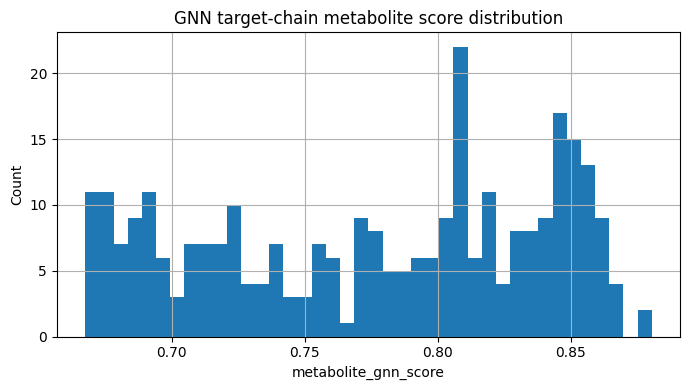

In [23]:

# ============================================================
# 16. v5 target-chain ranking and interpretable paths
# ============================================================
@torch.no_grad()
def rank_metabolites_via_target_chain(model, full_data, target_disease_edges, target2idx, idx2met, device, top_k=300):
    model.eval()
    full_data = full_data.to(device)
    z = model(full_data)
    met_emb = F.normalize(z["metabolite"], p=2, dim=1)
    tgt_emb = F.normalize(z["target"], p=2, dim=1)
    tgt_scores = target_disease_edges.groupby("target_id")["association_score"].max().reset_index()
    score = torch.zeros(met_emb.size(0), device=device)
    total_weight = 0.0
    for _, row in tgt_scores.iterrows():
        t = str(row["target_id"])
        if t not in target2idx:
            continue
        w = float(row["association_score"])
        t_vec = tgt_emb[target2idx[t]]
        sim = torch.sigmoid(5 * F.cosine_similarity(met_emb, t_vec.unsqueeze(0), dim=1))
        score += w * sim
        total_weight += w
    score = score / max(total_weight, 1e-12)
    top = torch.topk(score, k=min(top_k, score.size(0)))
    rows = []
    for rank, (idx, s) in enumerate(zip(top.indices.cpu().tolist(), top.values.cpu().tolist()), 1):
        rows.append({"rank": rank, "metabolite_name": idx2met[idx], "metabolite_gnn_score": float(s)})
    return pd.DataFrame(rows)

def build_path_explanation(metabolites_df, metabolite_drug_edges, drug_target_edges, target_disease_edges):
    rows = []
    for met in tqdm(metabolites_df["metabolite_name"].unique(), desc="Path explanations"):
        sim_hits = metabolite_drug_edges[metabolite_drug_edges["metabolite_name"] == met]
        for _, sim in sim_hits.iterrows():
            drug = sim["drug_name"]
            tanimoto = float(sim["tanimoto"])
            dt_hits = drug_target_edges[drug_target_edges["drug_name"] == drug]
            for _, dt in dt_hits.iterrows():
                target = dt["target_id"]
                dt_conf = float(dt["confidence"])
                td_hits = target_disease_edges[target_disease_edges["target_id"] == target]
                for _, td in td_hits.iterrows():
                    disease_score = float(td.get("association_score", 1.0))
                    rows.append({
                        "metabolite_name": met,
                        "similar_drug": drug,
                        "target": target,
                        "disease": "ALOPECIA",
                        "tanimoto": tanimoto,
                        "drug_target_confidence": dt_conf,
                        "target_disease_score": disease_score,
                        "path_score": tanimoto * dt_conf * disease_score,
                    })
    return pd.DataFrame(rows)

metabolite_rank_df = rank_metabolites_via_target_chain(model, data, target_disease_edges, target2idx, idx2met, DEVICE, TOP_K_RANK)
path_df = build_path_explanation(metabolites_df, metabolite_drug_edges, drug_target_edges, target_disease_edges)

print("GNN target-chain ranking rows:", len(metabolite_rank_df))
print("Interpretable path rows:", len(path_df))
display(metabolite_rank_df.head(20))
display(path_df.sort_values("path_score", ascending=False).head(20))

plt.figure(figsize=(7,4))
metabolite_rank_df["metabolite_gnn_score"].hist(bins=40)
plt.title("GNN target-chain metabolite score distribution")
plt.xlabel("metabolite_gnn_score")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [24]:

# ============================================================
# 17. Evidence-calibrated final ranking functions
# ============================================================
def robust_minmax(series, lower_q=0.05, upper_q=0.95, neutral=0.5):
    x = pd.Series(series).astype(float).replace([np.inf, -np.inf], np.nan).fillna(0.0)
    if len(x) == 0:
        return x
    lo, hi = x.quantile(lower_q), x.quantile(upper_q)
    if not np.isfinite(lo) or not np.isfinite(hi) or hi <= lo:
        lo, hi = x.min(), x.max()
    if hi > lo:
        return ((x.clip(lo, hi) - lo) / (hi - lo)).clip(0,1)
    return pd.Series(np.full(len(x), neutral), index=x.index, dtype=float)

def sigmoid_score(x, midpoint=0.45, temperature=0.07):
    x = pd.Series(x).astype(float).replace([np.inf, -np.inf], np.nan).fillna(0.0)
    temp = max(float(temperature), 1e-6)
    return 1.0 / (1.0 + np.exp(-(x - float(midpoint)) / temp))

def canonical_target_symbol(target):
    t = str(target).upper().strip()
    t = re.sub(r"_HUMAN$", "", t)
    t = re.sub(r"[^A-Z0-9]", "", t)
    return t

def get_alopecia_target_priority(mode="AGA"):
    mode = str(mode).upper()
    aga_high = {"AR", "SRD5A1", "SRD5A2", "PTGDR2", "GPR44", "PTGDS", "CTNNB1", "WNT10A", "WNT10B", "GSK3B", "DKK1", "LEF1"}
    aga_mid = {"VEGFA", "KDR", "FLT1", "HIF1A", "IGF1", "IGF1R", "FGF5", "FGF7", "FGFR1", "FGFR2", "TGFB1", "TGFB2", "TGFB3", "TGFBR1", "TGFBR2", "BMP2", "BMP4", "BMPR1A", "SHH", "SMO", "GLI1", "PTGS1", "PTGS2", "PTGES", "CYP19A1", "ESR1", "ESR2"}
    aga_low = {"IL6", "TNF", "NFKB1", "RELA", "PPARG", "AKT1", "MTOR", "MAPK1", "MAPK3", "EGFR", "CASP3", "BCL2", "SOD1", "CAT"}
    aa_high = {"JAK1", "JAK2", "JAK3", "TYK2", "STAT1", "STAT3", "STAT5A", "STAT5B", "IFNG", "IL15", "IL15RA", "IL2RG", "CXCL9", "CXCL10", "CXCL11"}
    aa_mid = {"IL2", "IL7", "IL21", "IL12A", "IL12B", "TNF", "NFKB1", "RELA", "CTLA4"}
    priority = {}
    if mode in {"AGA", "MIXED"}:
        priority.update({t: 1.00 for t in aga_high})
        priority.update({t: max(priority.get(t, 0), 0.75) for t in aga_mid})
        priority.update({t: max(priority.get(t, 0), 0.45) for t in aga_low})
    if mode in {"AA", "MIXED"}:
        priority.update({t: max(priority.get(t, 0), 1.00) for t in aa_high})
        priority.update({t: max(priority.get(t, 0), 0.70) for t in aa_mid})
    return priority

def artifact_penalty_from_name(name):
    n = str(name).lower()
    penalty = 0.0
    severe = [r"\b(isobutanol|butanol|ethanol|methanol|propanol|methylbutanol|methionol)\b", r"acetaldehyde", r"phenylacetaldehyde", r"aldehyde"]
    sugar = [r"glucopyranose", r"galactopyranose", r"mannopyranose", r"fructofuranose", r"\bglucose\b", r"\bgalactose\b", r"\bmannose\b", r"\bfructose\b", r"trehalose", r"sucrose"]
    cofactor = [r"\batp\b", r"\badp\b", r"\bamp\b", r"\bgtp\b", r"\bgdp\b", r"\bnad", r"coenzyme a", r"\bcoa\b", r"thiamine diphosphate", r"tetrahydrofolate", r"phosphate", r"diphosphate", r"pyrophosphate"]
    if any(re.search(p, n) for p in severe): penalty = max(penalty, 0.90)
    if any(re.search(p, n) for p in sugar): penalty = max(penalty, 0.75)
    if any(re.search(p, n) for p in cofactor): penalty = max(penalty, 0.65)
    if any(k in n for k in ["ergosterol", "zymosterol", "lanosterol", "squalene", "ubiquinone", "ubiquinol"]):
        penalty = min(penalty, 0.15)
    return float(penalty)

def artifact_penalty_from_smiles(smiles):
    mol = smiles_to_mol(smiles)
    if mol is None:
        return 0.0
    mw = Descriptors.MolWt(mol); heavy = mol.GetNumHeavyAtoms()
    hetero = sum(1 for a in mol.GetAtoms() if a.GetAtomicNum() not in (1, 6))
    hetero_ratio = hetero / max(1, heavy)
    penalty = 0.0
    if mw < 85 or heavy < 6: penalty = max(penalty, 0.55)
    if heavy <= 20 and hetero_ratio >= 0.55: penalty = max(penalty, 0.45)
    return float(penalty)

def build_final_ranking(metabolite_rank_df, path_df, metabolites_df, disease_id="ALOPECIA", alopecia_mode="AGA",
                        candidate_min_tanimoto=0.25, tanimoto_midpoint=0.45, tanimoto_temperature=0.07,
                        w_gnn=0.25, w_path=0.25, w_chem=0.20, w_target=0.20, w_breadth=0.10,
                        artifact_penalty_strength=0.55):
    target_priority_map = get_alopecia_target_priority(alopecia_mode)
    path_df = path_df.copy()
    if len(path_df) > 0:
        path_df = path_df[path_df["disease"] == disease_id].copy()
        path_df["target_symbol_norm"] = path_df["target"].apply(canonical_target_symbol)
        path_df["target_priority"] = path_df["target_symbol_norm"].map(target_priority_map).fillna(0.0)
        path_df["weighted_path_score"] = path_df["path_score"].astype(float) * path_df["target_priority"].astype(float)
        path_df["is_high_quality_path"] = ((path_df["target_priority"] >= 0.45) & (path_df["tanimoto"] >= 0.35)).astype(int)
        def summarize(g):
            top_tani = g["tanimoto"].sort_values(ascending=False).head(3)
            top_weighted = g["weighted_path_score"].sort_values(ascending=False).head(3)
            weights = g["path_score"].clip(lower=0).to_numpy(float)
            priorities = g["target_priority"].to_numpy(float)
            target_rel = float(np.average(priorities, weights=weights+1e-12)) if weights.sum()>0 else float(np.max(priorities) if len(priorities) else 0)
            best_idx = g["weighted_path_score"].idxmax() if g["weighted_path_score"].max() > 0 else g["path_score"].idxmax()
            best_row = g.loc[best_idx]
            return pd.Series({
                "best_path_score": float(g["path_score"].max()),
                "best_weighted_path_score": float(g["weighted_path_score"].max()),
                "sum_top3_weighted_path_score": float(top_weighted.sum()),
                "num_paths": int(len(g)),
                "num_unique_drugs": int(g["similar_drug"].nunique()),
                "num_unique_targets": int(g["target"].nunique()),
                "max_tanimoto": float(g["tanimoto"].max()),
                "mean_top3_tanimoto": float(top_tani.mean()) if len(top_tani) else 0.0,
                "target_relevance_score": float(np.clip(target_rel,0,1)),
                "high_quality_paths": int(g["is_high_quality_path"].sum()),
                "best_similar_drug": best_row.get("similar_drug", ""),
                "best_target": best_row.get("target", ""),
            })
        met_path = path_df.groupby("metabolite_name", group_keys=False).apply(summarize).reset_index()
    else:
        met_path = pd.DataFrame(columns=["metabolite_name"])
    base = metabolite_rank_df.copy()
    if len(met_path):
        path_candidates = met_path[(met_path["max_tanimoto"] >= candidate_min_tanimoto) | (met_path["best_weighted_path_score"] > 0)][["metabolite_name"]]
        base = pd.concat([base, path_candidates], ignore_index=True, sort=False)
    base = base.drop_duplicates("metabolite_name").reset_index(drop=True)
    out = base.merge(met_path, on="metabolite_name", how="left")
    numeric = ["best_path_score","best_weighted_path_score","sum_top3_weighted_path_score","num_paths","num_unique_drugs","num_unique_targets","max_tanimoto","mean_top3_tanimoto","target_relevance_score","high_quality_paths"]
    for c in numeric:
        if c not in out.columns: out[c] = 0.0
        out[c] = out[c].fillna(0.0).astype(float)
    for c in ["best_similar_drug","best_target"]:
        if c not in out.columns: out[c] = ""
        out[c] = out[c].fillna("")
    if "metabolite_gnn_score" not in out.columns:
        out["metabolite_gnn_score"] = np.nan
    min_gnn = out["metabolite_gnn_score"].min(skipna=True)
    min_gnn = 0.0 if pd.isna(min_gnn) else min_gnn
    out["added_by_path_evidence"] = out["metabolite_gnn_score"].isna()
    out["metabolite_gnn_score"] = out["metabolite_gnn_score"].fillna(min_gnn).astype(float)
    out = out.merge(metabolites_df[["metabolite_name","smiles"]].drop_duplicates("metabolite_name"), on="metabolite_name", how="left")
    out["artifact_penalty"] = np.maximum(out["metabolite_name"].apply(artifact_penalty_from_name), out["smiles"].apply(artifact_penalty_from_smiles)).clip(0,1)
    out["gnn_score_scaled"] = robust_minmax(out["metabolite_gnn_score"], neutral=0.5)
    out["path_score_scaled"] = robust_minmax(np.log1p(out["sum_top3_weighted_path_score"]), neutral=0.0)
    out["chem_similarity_score"] = (0.70*sigmoid_score(out["max_tanimoto"], tanimoto_midpoint, tanimoto_temperature) +
                                    0.30*sigmoid_score(out["mean_top3_tanimoto"], max(0.30, tanimoto_midpoint-0.10), tanimoto_temperature)).clip(0,1)
    out.loc[out["max_tanimoto"] < 0.20, "chem_similarity_score"] = 0.0
    breadth_drug = np.log1p(out["num_unique_drugs"]) / np.log1p(4)
    breadth_tgt = np.log1p(out["num_unique_targets"]) / np.log1p(4)
    out["evidence_breadth_score"] = (0.5*breadth_drug + 0.5*breadth_tgt).clip(0,1)
    weight_sum = w_gnn+w_path+w_chem+w_target+w_breadth
    out["raw_evidence_score"] = (w_gnn*out["gnn_score_scaled"] + w_path*out["path_score_scaled"] + w_chem*out["chem_similarity_score"] + w_target*out["target_relevance_score"] + w_breadth*out["evidence_breadth_score"]) / weight_sum
    out["final_score"] = (out["raw_evidence_score"] * (1 - artifact_penalty_strength*out["artifact_penalty"])).clip(0,1)
    out = out.sort_values(["final_score","target_relevance_score","max_tanimoto","path_score_scaled","gnn_score_scaled"], ascending=[False,False,False,False,False]).reset_index(drop=True)
    out["final_rank"] = np.arange(1, len(out)+1)
    return out

Final evidence-calibrated ranking rows: 396


[12:15:43] WARNING: not removing hydrogen atom without neighbors
[12:15:43] WARNING: not removing hydrogen atom without neighbors
[12:15:43] WARNING: not removing hydrogen atom without neighbors
[12:15:43] WARNING: not removing hydrogen atom without neighbors
[12:15:43] WARNING: not removing hydrogen atom without neighbors
[12:15:43] WARNING: not removing hydrogen atom without neighbors
[12:15:43] WARNING: not removing hydrogen atom without neighbors
[12:15:43] WARNING: not removing hydrogen atom without neighbors


,final_rank,metabolite_name,final_score,metabolite_gnn_score,sum_top3_weighted_path_score,max_tanimoto,target_relevance_score,artifact_penalty,best_similar_drug,best_target
0,1,myo-inositol,0.735130,0.861503,0.447438,0.454545,0.069307,0.0,CHEMBL501355,WNT10A
1,2,phosphoinositol-alpha-mannoside,0.600833,0.868688,0.291621,0.214286,0.069307,0.0,CHEMBL2442258,WNT10A
2,3,an alpha-limit dextrin,0.598471,0.853785,0.291621,0.214286,0.069307,0.0,CHEMBL2442258,WNT10A
3,4,"D-arabinono-1,4-lactone",0.596300,0.830532,0.324007,0.250000,0.069307,0.0,CHEMBL501355,WNT10A
4,5,"4alpha-carboxy-5alpha-cholesta-8,24-dien-3beta-ol",0.566349,0.781040,0.356232,0.258824,0.244320,0.0,CHEMBL1908332,SRD5A2
5,6,"4alpha-carboxy-4beta-methyl-5alpha-cholesta-8,...",0.564049,0.787501,0.343243,0.244186,0.200383,0.0,CHEMBL1908332,SRD5A2
6,7,prenol,0.563218,0.833042,0.279649,0.217391,0.069307,0.0,CHEMBL2442258,WNT10A
7,8,30-oxolanosterol,0.561410,0.695492,0.305892,0.195402,1.000000,0.0,CHEMBL24464,SRD5A2
8,9,"4alpha-formyl-4beta-methyl-5alpha-cholesta-8,2...",0.559047,0.778731,0.333236,0.250000,0.228156,0.0,CHEMBL1908332,SRD5A2
9,10,cytidine,0.553596,0.846051,0.243027,0.208333,0.069307,0.0,CHEMBL2442258,WNT10A


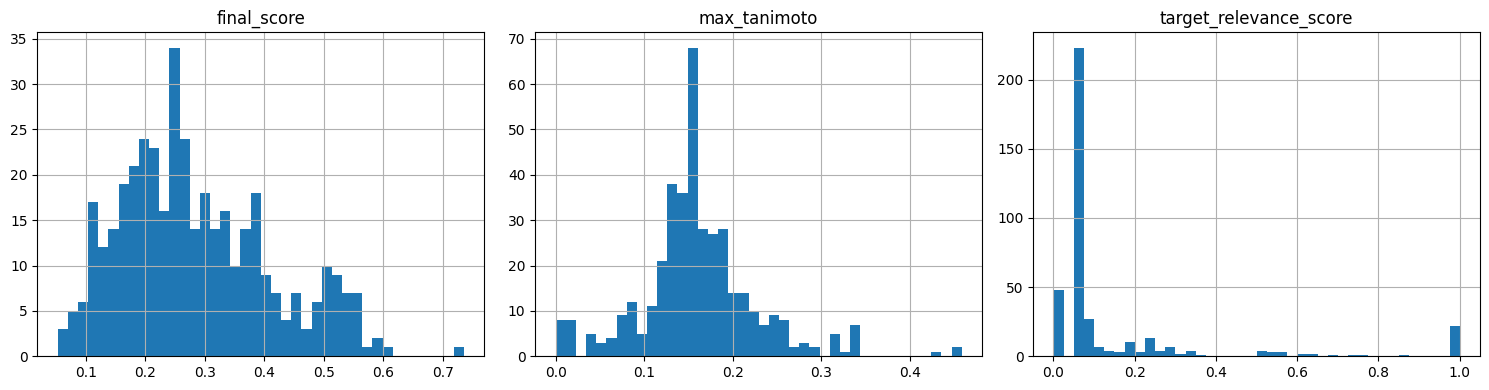

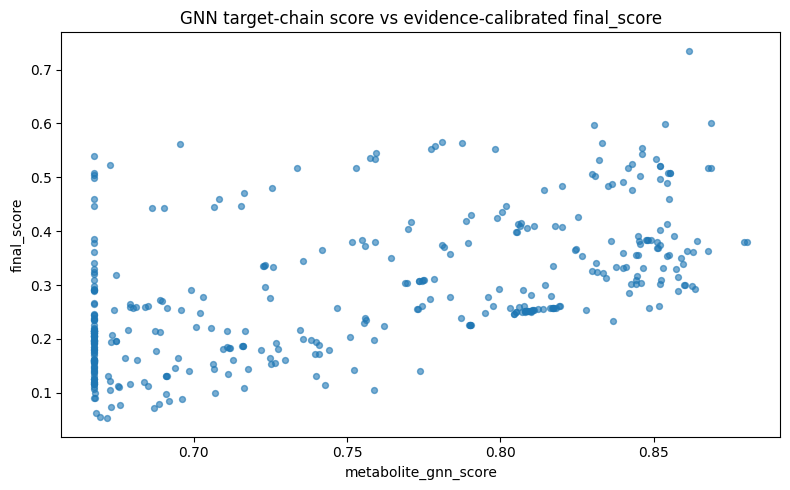

In [25]:

# ============================================================
# 18. Build and visualize v5 final ranking
# ============================================================
final_ranking_df = build_final_ranking(
    metabolite_rank_df, path_df, metabolites_df,
    alopecia_mode=ALOPECIA_MODE,
    candidate_min_tanimoto=CANDIDATE_MIN_TANIMOTO,
    tanimoto_midpoint=TANIMOTO_MIDPOINT,
    tanimoto_temperature=TANIMOTO_TEMPERATURE,
    artifact_penalty_strength=ARTIFACT_PENALTY_STRENGTH,
)

print("Final evidence-calibrated ranking rows:", len(final_ranking_df))
display(final_ranking_df[["final_rank","metabolite_name","final_score","metabolite_gnn_score","sum_top3_weighted_path_score","max_tanimoto","target_relevance_score","artifact_penalty","best_similar_drug","best_target"]].head(30))

fig, axes = plt.subplots(1, 3, figsize=(15,4))
final_ranking_df["final_score"].hist(bins=40, ax=axes[0]); axes[0].set_title("final_score")
final_ranking_df["max_tanimoto"].hist(bins=40, ax=axes[1]); axes[1].set_title("max_tanimoto")
final_ranking_df["target_relevance_score"].hist(bins=40, ax=axes[2]); axes[2].set_title("target_relevance_score")
plt.tight_layout(); plt.show()

plt.figure(figsize=(8,5))
plt.scatter(final_ranking_df["metabolite_gnn_score"], final_ranking_df["final_score"], s=18, alpha=0.6)
plt.xlabel("metabolite_gnn_score")
plt.ylabel("final_score")
plt.title("GNN target-chain score vs evidence-calibrated final_score")
plt.tight_layout()
plt.show()

## Part B. v7 validation code in notebook cells

v7의 목적은 ranking을 다시 예쁘게 만드는 것이 아니라, **GNN top metabolites가 특정 pathway에 무작위보다 강하게 농축되는지** 검증하는 것이다.

중요한 점:

- `real_drug_score.csv`는 이 validation score에 사용하지 않는다.
- null model은 두 종류다: simple random, pathway-degree-matched random.
- pathway-overlap network는 검증이 아니라 enriched pathway를 요약하는 visualization이다.

All final ranking rows: 396
Clean validation candidates: 313
Foreground top-N: 100


,metabolite_name,clean_for_validation,is_currency,is_pathway_hub,is_name_artifact
77,beta-D-mannopyranose,False,False,False,True
79,beta-D-glucopyranose,False,False,False,True
80,alpha-D-glucopyranose,False,False,False,True
81,beta-D-galactopyranose,False,False,False,True
83,alpha-D-galactopyranose,False,False,False,True
92,"alpha,alpha-trehalose",False,False,False,True
94,N-acetyl-alpha-D-glucosamine 1-phosphate,False,False,False,True
97,alpha-D-glucopyranose 1-phosphate,False,False,False,True
98,alpha-D-galactose 1-phosphate,False,False,False,True
101,alpha-D-ribose-1-phosphate,False,False,False,True


,final_rank,metabolite_name,validation_candidate_score,final_score,metabolite_gnn_score,max_tanimoto,target_relevance_score
0,1,myo-inositol,0.920338,0.735130,0.861503,0.454545,0.069307
1,2,phosphoinositol-alpha-mannoside,0.896349,0.600833,0.868688,0.214286,0.069307
2,3,an alpha-limit dextrin,0.894057,0.598471,0.853785,0.214286,0.069307
3,4,"D-arabinono-1,4-lactone",0.877806,0.596300,0.830532,0.250000,0.069307
4,7,prenol,0.863648,0.563218,0.833042,0.217391,0.069307
5,10,cytidine,0.858953,0.553596,0.846051,0.208333,0.069307
6,14,glycerol,0.855955,0.542963,0.846007,0.190476,0.069307
7,17,D-sorbitol,0.848921,0.534854,0.850797,0.173913,0.069307
8,19,uridine,0.840321,0.532686,0.832133,0.195122,0.069307
9,11,4alpha-hydroxymethyl-4beta-methyl-5alpha-chole...,0.839410,0.552908,0.798257,0.238095,0.187298


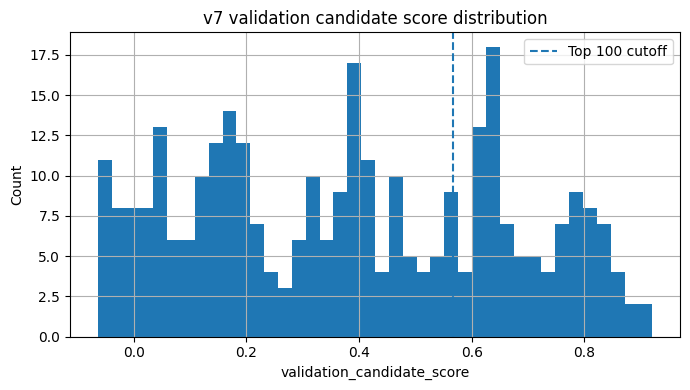

In [26]:

# ============================================================
# 19. v7 candidate cleaning and validation score
# ============================================================
def is_name_artifact(name):
    n = str(name).lower()
    patterns = [
        r"\b(h\+|h2o|water|co2|o2|phosphate|diphosphate|atp|adp|amp|gtp|gdp|nad|nadh|nadph|nadp)\b",
        r"\b(ethanol|methanol|propanol|butanol|methylbutanol|methionol|acetaldehyde|formaldehyde)\b",
        r"glucopyranose|fructofuranose|galactopyranose|mannopyranose|sucrose|trehalose",
        r"\[r\]|carrier protein|proteinogenic|group$|ring$",
    ]
    return any(re.search(p, n) for p in patterns)

def prepare_v7_candidates(final_df, pathway_membership, currency_set, pathway_hubs):
    df = final_df.copy()
    df["metabolite_key"] = df["metabolite_name"].apply(norm_name)
    df["is_currency"] = df["metabolite_key"].isin(currency_set)
    df["is_pathway_hub"] = df["metabolite_key"].isin(pathway_hubs)
    df["is_name_artifact"] = df["metabolite_name"].apply(is_name_artifact)
    df["clean_for_validation"] = ~(df["is_currency"] | df["is_pathway_hub"] | df["is_name_artifact"])
    clean = df[df["clean_for_validation"]].copy().reset_index(drop=True)

    # Transparent validation score without drug score.
    clean["rank_position_score"] = 1.0 - (clean["final_rank"].astype(float) - 1) / max(len(clean)-1, 1)
    clean["v_final_scaled"] = robust_minmax(clean["final_score"], neutral=0.5)
    clean["v_gnn_scaled"] = robust_minmax(clean["metabolite_gnn_score"], neutral=0.5)
    clean["v_path_scaled"] = robust_minmax(np.log1p(clean["sum_top3_weighted_path_score"]), neutral=0.0)
    clean["v_tani_soft"] = sigmoid_score(clean["max_tanimoto"], midpoint=0.45, temperature=0.07)
    clean["validation_candidate_score"] = (
        0.30 * clean["v_final_scaled"] +
        0.25 * clean["rank_position_score"] +
        0.20 * clean["v_gnn_scaled"] +
        0.15 * clean["v_path_scaled"] +
        0.07 * clean["target_relevance_score"].fillna(0.0).astype(float) +
        0.03 * clean["v_tani_soft"]
    )
    clean = clean.sort_values("validation_candidate_score", ascending=False).reset_index(drop=True)
    return df, clean

candidate_audit_df, clean_candidates_df = prepare_v7_candidates(final_ranking_df, pathway_membership, all_currency, pathway_hubs)
foreground_df = clean_candidates_df.head(TOP_N_VALIDATION).copy()
background_keys = set(clean_candidates_df["metabolite_key"])
foreground_keys = set(foreground_df["metabolite_key"])

print("All final ranking rows:", len(final_ranking_df))
print("Clean validation candidates:", len(clean_candidates_df))
print("Foreground top-N:", len(foreground_df))
display(candidate_audit_df[["metabolite_name","clean_for_validation","is_currency","is_pathway_hub","is_name_artifact"]].query("clean_for_validation == False").head(20))
display(foreground_df[["final_rank","metabolite_name","validation_candidate_score","final_score","metabolite_gnn_score","max_tanimoto","target_relevance_score"]].head(20))

plt.figure(figsize=(7,4))
clean_candidates_df["validation_candidate_score"].hist(bins=40)
plt.axvline(foreground_df["validation_candidate_score"].min(), linestyle="--", label=f"Top {TOP_N_VALIDATION} cutoff")
plt.title("v7 validation candidate score distribution")
plt.xlabel("validation_candidate_score")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()

Tested pathways: 91


,pathway,module,pathway_size_in_background,selected_hits,expected_hits,observed_expected_ratio,hypergeom_p,hit_metabolite_keys,fdr_bh,neglog10_p
0,superpathway of ergosterol biosynthesis I,Sterol/isoprenoid,22,21,7.028754,2.987727,1.326089e-10,14-demethyllanosterol; 3-dehydro-4-methylzymos...,1.206741e-08,9.877427
1,zymosterol biosynthesis,Sterol/isoprenoid,15,15,4.792332,3.130000,1.718022e-08,14-demethyllanosterol; 3-dehydro-4-methylzymos...,7.817002e-07,7.764971
2,sphingolipid recycling and degradation (yeast),Sphingolipid/ceramide,9,8,2.875399,2.782222,5.871225e-04,(r)-2-hydroxyhexadecanal; 1d-myo-inositol 1-mo...,1.780938e-02,3.231271
3,ergosterol biosynthesis I,Sterol/isoprenoid,6,6,1.916933,3.130000,9.578503e-04,"episterol; ergosta-5,7,22,24(28)-tetraen-3beta...",2.179109e-02,3.018702
4,5-aminoimidazole ribonucleotide biosynthesis I,Nucleotide/salvage,5,5,1.597444,3.130000,3.105451e-03,2-(formamido)-n1-(5-phospho-beta-d-ribosyl)ace...,4.709935e-02,2.507875
5,sphingolipid biosynthesis (yeast),Sphingolipid/ceramide,5,5,1.597444,3.130000,3.105451e-03,3-dehydrosphinganine; c20 3-dehydrosphinganine...,4.709935e-02,2.507875
6,purine ribonucleosides degradation,Nucleotide/salvage,4,4,1.277955,3.130000,9.995672e-03,adenosine; guanosine; inosine; xanthosine,1.137008e-01,2.000188
7,sterol:steryl ester interconversion,Sterol/isoprenoid,4,4,1.277955,3.130000,9.995672e-03,ergosterol; ergosteryl oleate; lanosterol; lan...,1.137008e-01,2.000188
8,"D-myo-inositol (1,3,4)-trisphosphate biosynthesis",Other,3,3,0.958466,3.130000,3.194493e-02,"d-myo-inositol (1,3,4)-trisphosphate; d-myo-in...",2.642717e-01,1.495598
9,chitin biosynthesis,Carbohydrate/glycosylation,3,3,0.958466,3.130000,3.194493e-02,"alpha-d-glucose 1,6-bisphosphate; n-acetyl-d-g...",2.642717e-01,1.495598


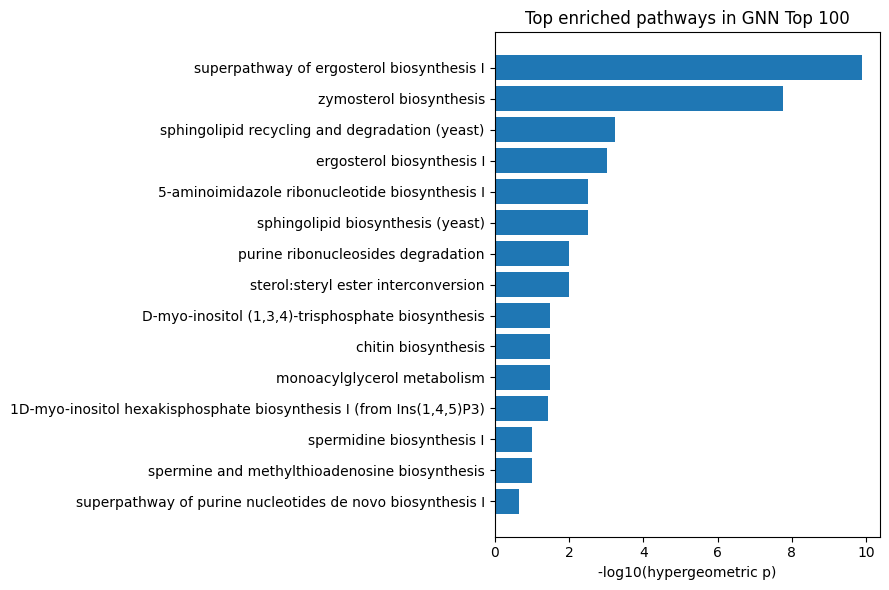

,module,n_pathways,min_p,max_neglog10_p,sum_top5_neglog10_p,total_hits
0,Sterol/isoprenoid,4,1.326089e-10,9.877427,22.661289,46
1,Sphingolipid/ceramide,2,5.871225e-04,3.231271,5.739147,13
2,Nucleotide/salvage,10,3.105451e-03,2.507875,5.520026,22
3,Other,52,3.194493e-02,1.495598,5.677041,42
4,Carbohydrate/glycosylation,1,3.194493e-02,1.495598,1.495598,3
5,Polyamine,2,9.779271e-02,1.009694,2.019387,6
6,Phospholipid/fatty acid,8,3.826851e-01,0.417158,0.834317,9
7,Vitamin/cofactor,8,6.229103e-01,0.205574,0.205574,4
8,Aromatic amino acid,4,1.000000e+00,-0.000000,0.000000,2


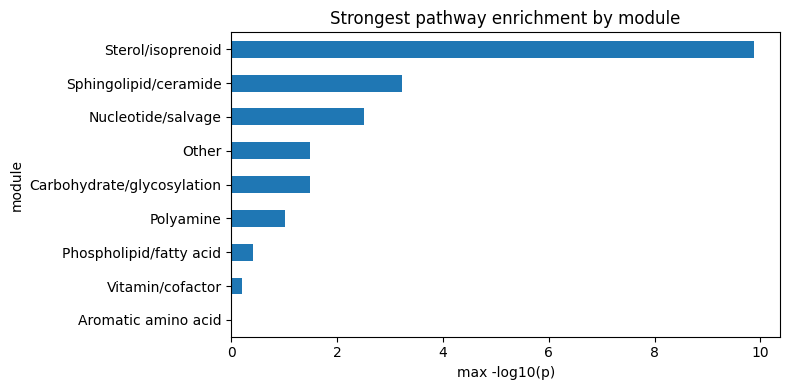

In [27]:

# ============================================================
# 20. Pathway enrichment test and BH-FDR correction
# ============================================================
def bh_fdr(pvals):
    p = np.asarray(pvals, dtype=float)
    n = len(p)
    order = np.argsort(p)
    ranked = p[order]
    q = ranked * n / (np.arange(n) + 1)
    q = np.minimum.accumulate(q[::-1])[::-1]
    out = np.empty(n, dtype=float)
    out[order] = np.clip(q, 0, 1)
    return out

def infer_module_from_pathway(pathway):
    p = str(pathway).lower()
    if any(k in p for k in ["ergosterol", "zymosterol", "sterol", "squalene", "mevalonate", "isoprenoid"]): return "Sterol/isoprenoid"
    if any(k in p for k in ["sphingo", "ceramide", "phytosphingosine", "sphinganine"]): return "Sphingolipid/ceramide"
    if any(k in p for k in ["phosphatidyl", "choline", "glycerolipid", "fatty acid", "oleate", "lipid"]): return "Phospholipid/fatty acid"
    if any(k in p for k in ["spermidine", "spermine", "putrescine", "polyamine"]): return "Polyamine"
    if any(k in p for k in ["biotin", "riboflavin", "pyridox", "thiamin", "lipoate", "folate"]): return "Vitamin/cofactor"
    if any(k in p for k in ["purine", "pyrimidine", "nucleotide", "adenosine", "salvage"]): return "Nucleotide/salvage"
    if any(k in p for k in ["chitin", "glucosamine", "udp", "glycosyl", "mannan"]): return "Carbohydrate/glycosylation"
    if any(k in p for k in ["chorismate", "phenylalanine", "tyrosine", "tryptophan", "aromatic"]): return "Aromatic amino acid"
    return "Other"

def make_pathway_sets(pathway_membership, allowed_keys, min_size=3):
    df = pathway_membership[pathway_membership["metabolite_key"].isin(allowed_keys)].drop_duplicates(["pathway","metabolite_key"])
    sets = {}
    for p, g in df.groupby("pathway"):
        s = set(g["metabolite_key"])
        if len(s) >= min_size:
            sets[p] = s
    return sets

def pathway_enrichment(pathway_sets, background_keys, foreground_keys, min_hits=2):
    N = len(background_keys); n = len(foreground_keys)
    rows = []
    for pathway, s in pathway_sets.items():
        bg_s = set(s) & background_keys
        K = len(bg_s)
        hits = bg_s & foreground_keys
        k = len(hits)
        if K == 0:
            continue
        expected = n * K / max(N, 1)
        pval = hypergeom.sf(k-1, N, K, n) if k >= min_hits else 1.0
        rows.append({
            "pathway": pathway,
            "module": infer_module_from_pathway(pathway),
            "pathway_size_in_background": K,
            "selected_hits": k,
            "expected_hits": expected,
            "observed_expected_ratio": k / expected if expected > 0 else np.nan,
            "hypergeom_p": pval,
            "hit_metabolite_keys": "; ".join(sorted(hits)),
        })
    out = pd.DataFrame(rows)
    if len(out):
        out["fdr_bh"] = bh_fdr(out["hypergeom_p"].values)
        out["neglog10_p"] = -np.log10(out["hypergeom_p"].clip(lower=1e-300))
        out = out.sort_values(["hypergeom_p", "observed_expected_ratio"], ascending=[True, False]).reset_index(drop=True)
    return out

pathway_sets = make_pathway_sets(pathway_membership, background_keys, MIN_PATHWAY_SIZE)
enrichment_df = pathway_enrichment(pathway_sets, background_keys, foreground_keys, MIN_HITS_FOR_ENRICHMENT)
print("Tested pathways:", len(pathway_sets))
display(enrichment_df.head(20))

# Barplot of top enriched pathways.
top_e = enrichment_df.head(15).iloc[::-1]
plt.figure(figsize=(9,6))
plt.barh(top_e["pathway"], top_e["neglog10_p"])
plt.xlabel("-log10(hypergeometric p)")
plt.title(f"Top enriched pathways in GNN Top {TOP_N_VALIDATION}")
plt.tight_layout()
plt.show()

# Module summary.
module_summary = enrichment_df.groupby("module").agg(
    n_pathways=("pathway", "count"),
    min_p=("hypergeom_p", "min"),
    max_neglog10_p=("neglog10_p", "max"),
    sum_top5_neglog10_p=("neglog10_p", lambda x: float(np.sort(x)[-5:].sum()) if len(x) else 0),
    total_hits=("selected_hits", "sum"),
).sort_values("max_neglog10_p", ascending=False).reset_index()
display(module_summary)

plt.figure(figsize=(8,4))
module_summary.sort_values("max_neglog10_p").plot(x="module", y="max_neglog10_p", kind="barh", legend=False, ax=plt.gca())
plt.title("Strongest pathway enrichment by module")
plt.xlabel("max -log10(p)")
plt.tight_layout()
plt.show()

Null permutations:   0%|          | 0/1000 [00:00<?, ?it/s]

Actual metrics: {'n_pathways_p_lt_alpha': 12, 'max_neglog10_p': 9.877427363825747, 'sum_top10_neglog10_p': 35.89969482257672}


,n_pathways_p_lt_alpha,max_neglog10_p,sum_top10_neglog10_p
0,12,9.877427,35.899695


,metric,actual,random_mean,random_95pct,random_empirical_p,degree_matched_mean,degree_matched_95pct,degree_matched_empirical_p
0,n_pathways_p_lt_alpha,12.000000,1.975000,5.000000,0.000999,2.252000,5.000000,0.000999
1,max_neglog10_p,9.877427,1.648213,2.507875,0.000999,1.743300,2.507875,0.000999
2,sum_top10_neglog10_p,35.899695,9.985582,13.315630,0.000999,10.563795,13.820963,0.000999


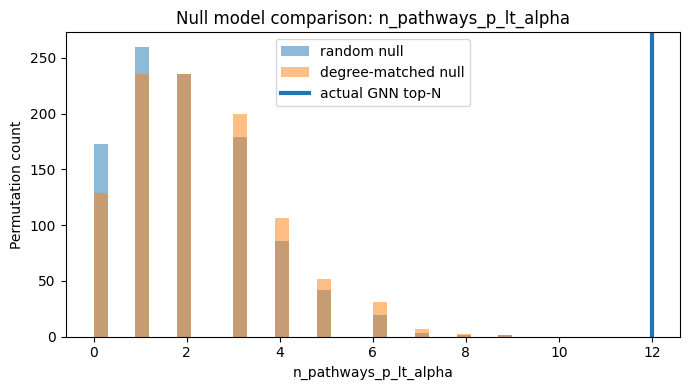

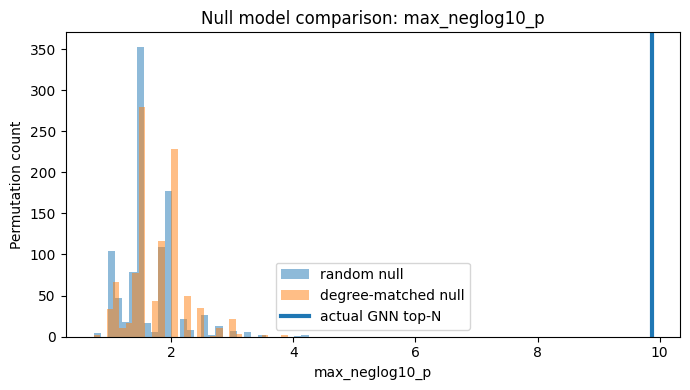

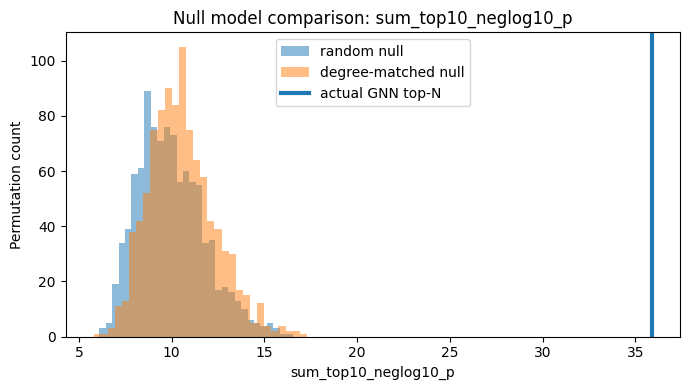

In [28]:

# ============================================================
# 21. Random and degree-matched null models
# ============================================================
# Precompute pathway-degree for each clean candidate.
pathway_degree_by_key = pathway_membership[pathway_membership["metabolite_key"].isin(background_keys)].groupby("metabolite_key")["pathway"].nunique().to_dict()
clean_candidates_df["pathway_degree"] = clean_candidates_df["metabolite_key"].map(pathway_degree_by_key).fillna(0).astype(int)
foreground_degrees = clean_candidates_df[clean_candidates_df["metabolite_key"].isin(foreground_keys)]["pathway_degree"].to_numpy()
background_by_degree = defaultdict(list)
for _, r in clean_candidates_df.iterrows():
    background_by_degree[int(r["pathway_degree"])].append(r["metabolite_key"])
all_background_list = list(background_keys)

def sample_random_foreground(n):
    return set(np.random.choice(all_background_list, size=min(n, len(all_background_list)), replace=False))

def sample_degree_matched_foreground(degrees):
    chosen = []
    used = set()
    degree_values = sorted(background_by_degree.keys())
    for d in degrees:
        # pick same degree if possible, otherwise nearest degree bin.
        candidates = [x for x in background_by_degree.get(int(d), []) if x not in used]
        if not candidates:
            nearest = sorted(degree_values, key=lambda z: abs(z-int(d)))
            for nd in nearest:
                candidates = [x for x in background_by_degree.get(nd, []) if x not in used]
                if candidates:
                    break
        if candidates:
            pick = random.choice(candidates)
            chosen.append(pick)
            used.add(pick)
    # fill if needed
    if len(chosen) < len(degrees):
        remain = [x for x in all_background_list if x not in used]
        if remain:
            chosen += list(np.random.choice(remain, size=min(len(degrees)-len(chosen), len(remain)), replace=False))
    return set(chosen)

def global_enrichment_metrics(enrich_df, alpha=0.05):
    if len(enrich_df) == 0:
        return {"n_pathways_p_lt_alpha": 0, "max_neglog10_p": 0, "sum_top10_neglog10_p": 0}
    return {
        "n_pathways_p_lt_alpha": int((enrich_df["hypergeom_p"] < alpha).sum()),
        "max_neglog10_p": float(enrich_df["neglog10_p"].max()),
        "sum_top10_neglog10_p": float(enrich_df["neglog10_p"].sort_values(ascending=False).head(10).sum()),
    }

actual_metrics = global_enrichment_metrics(enrichment_df, ALPHA)
random_metrics = []
degree_metrics = []
for i in tqdm(range(N_PERM), desc="Null permutations"):
    rf = sample_random_foreground(TOP_N_VALIDATION)
    re = pathway_enrichment(pathway_sets, background_keys, rf, MIN_HITS_FOR_ENRICHMENT)
    random_metrics.append(global_enrichment_metrics(re, ALPHA))

    dfm = sample_degree_matched_foreground(foreground_degrees)
    de = pathway_enrichment(pathway_sets, background_keys, dfm, MIN_HITS_FOR_ENRICHMENT)
    degree_metrics.append(global_enrichment_metrics(de, ALPHA))

random_null_df = pd.DataFrame(random_metrics)
degree_null_df = pd.DataFrame(degree_metrics)
print("Actual metrics:", actual_metrics)
display(pd.DataFrame([actual_metrics]))

# Summary with empirical p-values.
rows = []
for metric, actual in actual_metrics.items():
    r = random_null_df[metric].values
    d = degree_null_df[metric].values
    rows.append({
        "metric": metric,
        "actual": actual,
        "random_mean": float(np.mean(r)),
        "random_95pct": float(np.quantile(r, 0.95)),
        "random_empirical_p": float((np.sum(r >= actual) + 1) / (len(r) + 1)),
        "degree_matched_mean": float(np.mean(d)),
        "degree_matched_95pct": float(np.quantile(d, 0.95)),
        "degree_matched_empirical_p": float((np.sum(d >= actual) + 1) / (len(d) + 1)),
    })
null_summary_df = pd.DataFrame(rows)
display(null_summary_df)

# Histogram figures.
for metric in actual_metrics:
    plt.figure(figsize=(7,4))
    plt.hist(random_null_df[metric], bins=30, alpha=0.5, label="random null")
    plt.hist(degree_null_df[metric], bins=30, alpha=0.5, label="degree-matched null")
    plt.axvline(actual_metrics[metric], linewidth=3, label="actual GNN top-N")
    plt.title(f"Null model comparison: {metric}")
    plt.xlabel(metric)
    plt.ylabel("Permutation count")
    plt.legend()
    plt.tight_layout()
    plt.show()

Enriched pathway network nodes: 14 edges: 6


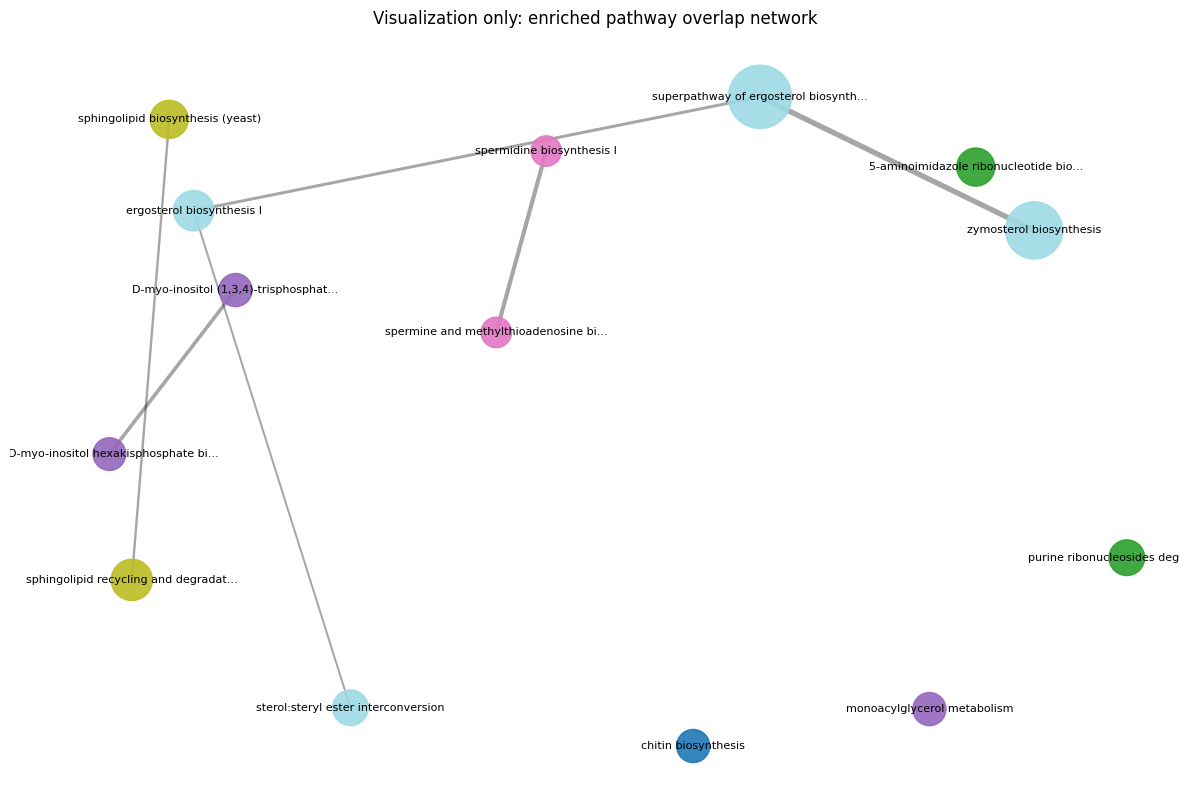

,module,color_id
0,Carbohydrate/glycosylation,0
1,Nucleotide/salvage,1
2,Other,2
3,Polyamine,3
4,Sphingolipid/ceramide,4
5,Sterol/isoprenoid,5


In [29]:

# ============================================================
# 22. Enriched pathway overlap network as visualization only
# ============================================================
# This network is not the main validation. It summarizes enriched pathways after enrichment/null testing.
sig_pathways = enrichment_df[(enrichment_df["selected_hits"] >= MIN_HITS_FOR_ENRICHMENT) & (enrichment_df["hypergeom_p"] < 0.10)].copy()
if len(sig_pathways) == 0:
    sig_pathways = enrichment_df.head(20).copy()

G = nx.Graph()
for _, r in sig_pathways.iterrows():
    G.add_node(r["pathway"], module=r["module"], neglog10_p=float(r["neglog10_p"]), hits=int(r["selected_hits"]))

sig_sets = {p: pathway_sets[p] & foreground_keys for p in sig_pathways["pathway"] if p in pathway_sets}
paths = list(sig_sets.keys())
for i in range(len(paths)):
    for j in range(i+1, len(paths)):
        a, b = paths[i], paths[j]
        A, B = sig_sets[a], sig_sets[b]
        if not A or not B:
            continue
        sim = len(A & B) / len(A | B)
        if sim >= 0.10:
            G.add_edge(a, b, weight=sim)

print("Enriched pathway network nodes:", G.number_of_nodes(), "edges:", G.number_of_edges())
if G.number_of_nodes() > 0:
    modules = sorted({G.nodes[n]["module"] for n in G.nodes})
    module_to_int = {m:i for i,m in enumerate(modules)}
    node_colors = [module_to_int[G.nodes[n]["module"]] for n in G.nodes]
    node_sizes = [300 + 180*G.nodes[n]["neglog10_p"] for n in G.nodes]
    pos = nx.spring_layout(G, seed=SEED, weight="weight", k=0.8)
    plt.figure(figsize=(12,8))
    nx.draw_networkx_edges(G, pos, alpha=0.35, width=[1+4*G[u][v]["weight"] for u,v in G.edges])
    nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=node_sizes, cmap="tab20", alpha=0.9)
    labels = {n: n[:35] + ("..." if len(n)>35 else "") for n in G.nodes}
    nx.draw_networkx_labels(G, pos, labels=labels, font_size=8)
    plt.title("Visualization only: enriched pathway overlap network")
    plt.axis("off")
    plt.tight_layout()
    plt.show()

    # Legend table.
    display(pd.DataFrame({"module": modules, "color_id": [module_to_int[m] for m in modules]}))

Metabolite feature clusters: 6 silhouette: 0.3555538367947153


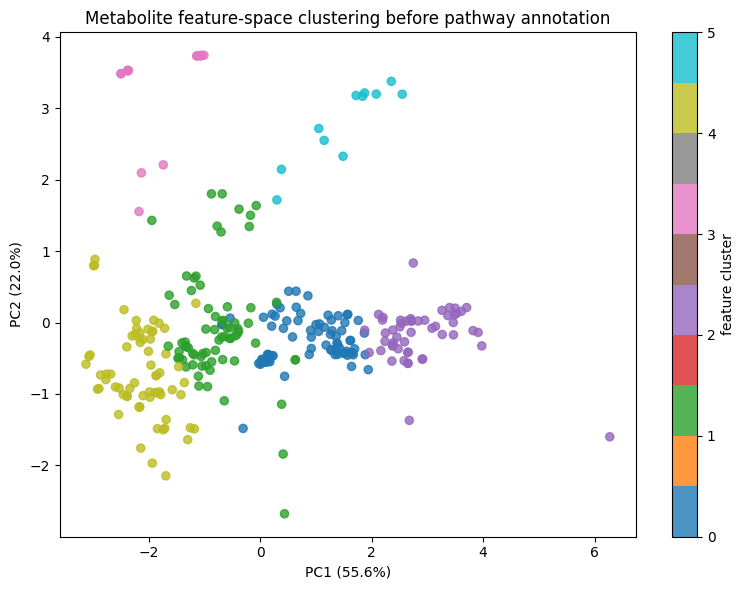

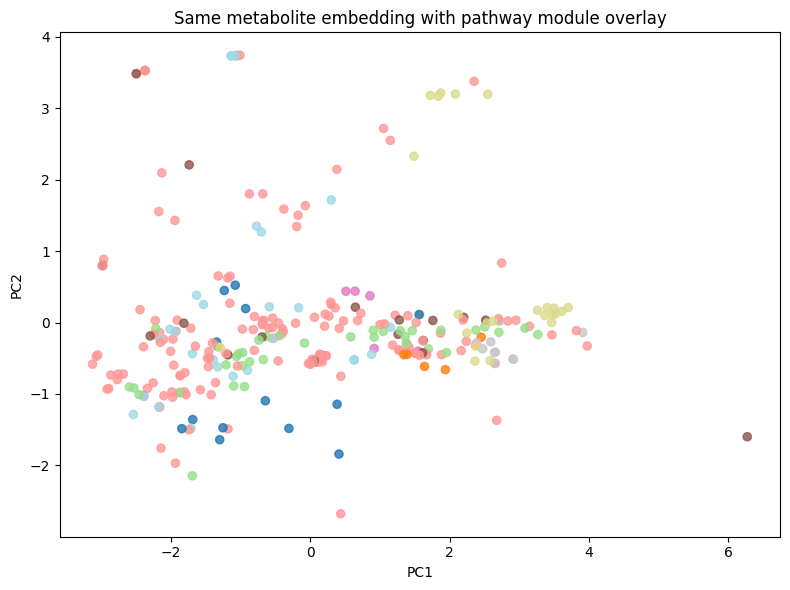

,module,color_id
0,Aromatic amino acid,0
1,Carbohydrate/glycosylation,1
2,Nucleotide/salvage,2
3,Other,3
4,Phospholipid/fatty acid,4
5,Polyamine,5
6,Sphingolipid/ceramide,6
7,Sterol/isoprenoid,7
8,Vitamin/cofactor,8


,metabolite_feature_cluster,pathway,module,selected_hits,observed_expected_ratio,hypergeom_p,fdr_bh
0,0,"9-cis, 11-trans-octadecadienoyl-CoA degradatio...",Other,10,3.439560,2.988140e-06,2.719208e-04
1,0,10-trans-heptadecenoyl-CoA degradation (reduct...,Other,8,3.057387,2.777504e-04,1.263764e-02
2,0,10-cis-heptadecenoyl-CoA degradation,Other,7,3.009615,9.013971e-04,2.050678e-02
3,0,inositol phosphate biosynthesis,Other,7,3.009615,9.013971e-04,2.050678e-02
4,0,1D-myo-inositol hexakisphosphate biosynthesis ...,Other,5,3.439560,1.918211e-03,3.491144e-02
5,1,superpathway of branched chain amino acid bios...,Other,8,3.118306,5.658147e-04,5.148914e-02
6,1,biotin biosynthesis from 8-amino-7-oxononanoate I,Vitamin/cofactor,6,3.215753,2.532298e-03,8.416100e-02
7,1,superpathway of adenosine nucleotides de novo ...,Nucleotide/salvage,4,4.287671,2.774538e-03,8.416100e-02
8,1,L-isoleucine biosynthesis I (from threonine),Other,3,4.287671,1.228724e-02,2.236278e-01
9,1,homofuraneol biosynthesis,Other,3,4.287671,1.228724e-02,2.236278e-01


In [30]:

# ============================================================
# 23. Metabolite-level feature clustering, then pathway labels overlaid after clustering
# ============================================================
# This is more non-circular than pathway-node clustering: cluster metabolites first, then test pathway enrichment within clusters.
feature_cols = ["final_score", "metabolite_gnn_score", "sum_top3_weighted_path_score", "max_tanimoto", "target_relevance_score", "validation_candidate_score"]
feat_df = clean_candidates_df.dropna(subset=feature_cols).copy()
X = feat_df[feature_cols].replace([np.inf, -np.inf], np.nan).fillna(0.0).to_numpy(float)
X_scaled = StandardScaler().fit_transform(X)

pca = PCA(n_components=2, random_state=SEED)
coords = pca.fit_transform(X_scaled)
feat_df["PC1"] = coords[:,0]
feat_df["PC2"] = coords[:,1]

# Choose a small K for interpretation; avoid forcing too many clusters.
K = 6 if len(feat_df) >= 60 else max(2, min(4, len(feat_df)//10))
kmeans = KMeans(n_clusters=K, random_state=SEED, n_init=20)
feat_df["metabolite_feature_cluster"] = kmeans.fit_predict(X_scaled)
try:
    sil = silhouette_score(X_scaled, feat_df["metabolite_feature_cluster"])
except Exception:
    sil = np.nan
print("Metabolite feature clusters:", K, "silhouette:", sil)

plt.figure(figsize=(8,6))
scatter = plt.scatter(feat_df["PC1"], feat_df["PC2"], c=feat_df["metabolite_feature_cluster"], s=35, alpha=0.8, cmap="tab10")
plt.title("Metabolite feature-space clustering before pathway annotation")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
plt.colorbar(scatter, label="feature cluster")
plt.tight_layout()
plt.show()

# Label each metabolite by strongest semantic module among its pathways.
key_to_modules = defaultdict(list)
for _, r in pathway_membership.iterrows():
    if r["metabolite_key"] in background_keys:
        key_to_modules[r["metabolite_key"]].append(infer_module_from_pathway(r["pathway"]))

def dominant_module_for_key(k):
    mods = [m for m in key_to_modules.get(k, []) if m != "Other"]
    if not mods:
        return "Other"
    return Counter(mods).most_common(1)[0][0]

feat_df["dominant_pathway_module"] = feat_df["metabolite_key"].apply(dominant_module_for_key)
modules = sorted(feat_df["dominant_pathway_module"].unique())
mod_to_int = {m:i for i,m in enumerate(modules)}
plt.figure(figsize=(8,6))
scatter = plt.scatter(feat_df["PC1"], feat_df["PC2"], c=feat_df["dominant_pathway_module"].map(mod_to_int), s=35, alpha=0.8, cmap="tab20")
plt.title("Same metabolite embedding with pathway module overlay")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.show()
display(pd.DataFrame({"module": modules, "color_id": [mod_to_int[m] for m in modules]}))

# Pathway enrichment per metabolite feature cluster.
cluster_enrichment_rows = []
for c, g in feat_df.groupby("metabolite_feature_cluster"):
    fg = set(g["metabolite_key"])
    e = pathway_enrichment(pathway_sets, background_keys, fg, MIN_HITS_FOR_ENRICHMENT)
    if len(e):
        top = e.head(5).copy()
        top["metabolite_feature_cluster"] = c
        cluster_enrichment_rows.append(top)
cluster_pathway_enrichment_df = pd.concat(cluster_enrichment_rows, ignore_index=True) if cluster_enrichment_rows else pd.DataFrame()
display(cluster_pathway_enrichment_df[["metabolite_feature_cluster","pathway","module","selected_hits","observed_expected_ratio","hypergeom_p","fdr_bh"]].head(30) if len(cluster_pathway_enrichment_df) else cluster_pathway_enrichment_df)

## Part C. Post-hoc real drug score annotation

`real_drug_score.csv`는 **여기서만** 사용한다.  
GNN 학습, evidence-calibrated ranking 계산, pathway enrichment, null model validation에는 사용하지 않았다.

목적은 단 하나다:

> GNN/pathway 기반 후보군 안에서 문헌 기반 drug 후보성이 높은 metabolite가 어디에 위치하는지 해석용으로 겹쳐 보기.

Post-hoc drug score annotation complete.
Total final ranking rows: 396
Matched drug-score rows: 31


,final_rank,metabolite_name,final_score,drug_ranking_score_0_14,drug_ranking_index,drug_evidence_tier,drug_score_posthoc_matched
0,1,myo-inositol,0.735130,6.7,26.0,D+: endocrine/metabolic support,True
1,2,phosphoinositol-alpha-mannoside,0.600833,0.0,,,False
2,3,an alpha-limit dextrin,0.598471,0.0,,,False
3,4,"D-arabinono-1,4-lactone",0.596300,0.0,,,False
4,5,"4alpha-carboxy-5alpha-cholesta-8,24-dien-3beta-ol",0.566349,0.0,,,False
5,6,"4alpha-carboxy-4beta-methyl-5alpha-cholesta-8,...",0.564049,0.0,,,False
6,7,prenol,0.563218,0.0,,,False
7,8,30-oxolanosterol,0.561410,0.0,,,False
8,9,"4alpha-formyl-4beta-methyl-5alpha-cholesta-8,2...",0.559047,0.0,,,False
9,10,cytidine,0.553596,0.0,,,False


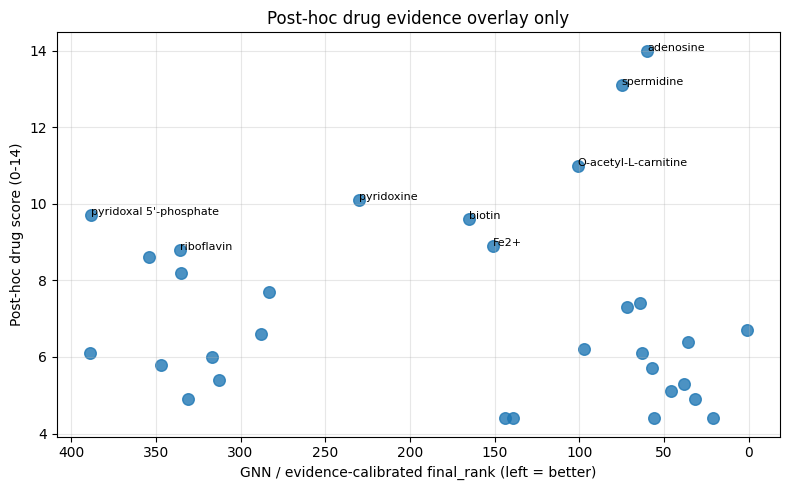


1) Top GNN / evidence-calibrated metabolites


,final_rank,metabolite_name,final_score,metabolite_gnn_score,max_tanimoto,target_relevance_score,best_similar_drug,best_target
0,1,myo-inositol,0.735130,0.861503,0.454545,0.069307,CHEMBL501355,WNT10A
1,2,phosphoinositol-alpha-mannoside,0.600833,0.868688,0.214286,0.069307,CHEMBL2442258,WNT10A
2,3,an alpha-limit dextrin,0.598471,0.853785,0.214286,0.069307,CHEMBL2442258,WNT10A
3,4,"D-arabinono-1,4-lactone",0.596300,0.830532,0.250000,0.069307,CHEMBL501355,WNT10A
4,5,"4alpha-carboxy-5alpha-cholesta-8,24-dien-3beta-ol",0.566349,0.781040,0.258824,0.244320,CHEMBL1908332,SRD5A2
5,6,"4alpha-carboxy-4beta-methyl-5alpha-cholesta-8,...",0.564049,0.787501,0.244186,0.200383,CHEMBL1908332,SRD5A2
6,7,prenol,0.563218,0.833042,0.217391,0.069307,CHEMBL2442258,WNT10A
7,8,30-oxolanosterol,0.561410,0.695492,0.195402,1.000000,CHEMBL24464,SRD5A2
8,9,"4alpha-formyl-4beta-methyl-5alpha-cholesta-8,2...",0.559047,0.778731,0.250000,0.228156,CHEMBL1908332,SRD5A2
9,10,cytidine,0.553596,0.846051,0.208333,0.069307,CHEMBL2442258,WNT10A



2) Top enriched pathways with null-model context


,pathway,module,selected_hits,expected_hits,observed_expected_ratio,hypergeom_p,fdr_bh,neglog10_p
0,superpathway of ergosterol biosynthesis I,Sterol/isoprenoid,21,7.028754,2.987727,1.326089e-10,1.206741e-08,9.877427
1,zymosterol biosynthesis,Sterol/isoprenoid,15,4.792332,3.130000,1.718022e-08,7.817002e-07,7.764971
2,sphingolipid recycling and degradation (yeast),Sphingolipid/ceramide,8,2.875399,2.782222,5.871225e-04,1.780938e-02,3.231271
3,ergosterol biosynthesis I,Sterol/isoprenoid,6,1.916933,3.130000,9.578503e-04,2.179109e-02,3.018702
4,5-aminoimidazole ribonucleotide biosynthesis I,Nucleotide/salvage,5,1.597444,3.130000,3.105451e-03,4.709935e-02,2.507875
5,sphingolipid biosynthesis (yeast),Sphingolipid/ceramide,5,1.597444,3.130000,3.105451e-03,4.709935e-02,2.507875
6,purine ribonucleosides degradation,Nucleotide/salvage,4,1.277955,3.130000,9.995672e-03,1.137008e-01,2.000188
7,sterol:steryl ester interconversion,Sterol/isoprenoid,4,1.277955,3.130000,9.995672e-03,1.137008e-01,2.000188
8,"D-myo-inositol (1,3,4)-trisphosphate biosynthesis",Other,3,0.958466,3.130000,3.194493e-02,2.642717e-01,1.495598
9,chitin biosynthesis,Carbohydrate/glycosylation,3,0.958466,3.130000,3.194493e-02,2.642717e-01,1.495598



3) Global null comparison


,metric,actual,random_mean,random_95pct,random_empirical_p,degree_matched_mean,degree_matched_95pct,degree_matched_empirical_p
0,n_pathways_p_lt_alpha,12.000000,1.975000,5.000000,0.000999,2.252000,5.000000,0.000999
1,max_neglog10_p,9.877427,1.648213,2.507875,0.000999,1.743300,2.507875,0.000999
2,sum_top10_neglog10_p,35.899695,9.985582,13.315630,0.000999,10.563795,13.820963,0.000999



4) Module-level enrichment summary


,module,n_pathways,min_p,max_neglog10_p,sum_top5_neglog10_p,total_hits
0,Sterol/isoprenoid,4,1.326089e-10,9.877427,22.661289,46
1,Sphingolipid/ceramide,2,5.871225e-04,3.231271,5.739147,13
2,Nucleotide/salvage,10,3.105451e-03,2.507875,5.520026,22
3,Other,52,3.194493e-02,1.495598,5.677041,42
4,Carbohydrate/glycosylation,1,3.194493e-02,1.495598,1.495598,3
5,Polyamine,2,9.779271e-02,1.009694,2.019387,6
6,Phospholipid/fatty acid,8,3.826851e-01,0.417158,0.834317,9
7,Vitamin/cofactor,8,6.229103e-01,0.205574,0.205574,4
8,Aromatic amino acid,4,1.000000e+00,-0.000000,0.000000,2



5) Post-hoc drug evidence overlay, not used in model/validation


,final_rank,metabolite_name,final_score,drug_ranking_score_0_14,drug_ranking_index,drug_evidence_tier
59,60,adenosine,0.425176,14.0,1.0,A: human topical alopecia clinical evidence
74,75,spermidine,0.390966,13.1,2.0,A-: human supplement + human follicle evidence
100,101,O-acetyl-L-carnitine,0.364968,11.0,5.0,B: carnitine-related druggable analog
229,230,pyridoxine,0.248699,10.1,7.0,B-: B6/nutritional-combination evidence
387,388,pyridoxal 5'-phosphate,0.088772,9.7,8.0,B-: active B6 cofactor
164,165,biotin,0.291500,9.6,9.0,B-/C+: deficiency-specific support
150,151,Fe2+,0.303730,8.9,11.0,C+: deficiency-correction therapy
335,336,riboflavin,0.157487,8.8,12.0,C+: vitamin/cofactor support
353,354,nicotinamide,0.137557,8.6,13.0,C+: conflicting hair-growth evidence
334,335,(R)-lipoate,0.158493,8.2,16.0,C: antioxidant/metabolic support


In [36]:
# ============================================================
# Final cell replacement.
# Robust post-hoc real drug score annotation + interpretation tables
# axis error 방지 버전
# ============================================================

import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path


# ------------------------------------------------------------
# 1. Safe name normalization
# ------------------------------------------------------------
def safe_norm_name(x):
    if x is None:
        return ""
    s = str(x).strip()

    replacements = {
        "&alpha;": "alpha",
        "&beta;": "beta",
        "&gamma;": "gamma",
        "&delta;": "delta",
        "&omega;": "omega",
        "&rarr;": "→",
        "&lt;": "<",
        "&gt;": ">",
        "&amp;": "&",
        "<i>": "",
        "</i>": "",
        "<sup>": "",
        "</sup>": "",
        "<sub>": "",
        "</sub>": "",
    }

    for a, b in replacements.items():
        s = s.replace(a, b)

    s = re.sub(r"<[^>]+>", "", s)
    s = re.sub(r"\s+", " ", s).strip().lower()

    if "COMPOUND_SYNONYMS" in globals():
        s = COMPOUND_SYNONYMS.get(s, s)

    return s


# ------------------------------------------------------------
# 2. Robust post-hoc annotation
# ------------------------------------------------------------
def annotate_real_drug_score_posthoc_fixed(final_df, drug_score_file):
    if final_df is None or len(final_df) == 0:
        print("final_ranking_df is empty.")
        return pd.DataFrame(), pd.DataFrame()

    if drug_score_file is None or not Path(str(drug_score_file)).exists():
        print("No real_drug_score.csv uploaded. Skipping post-hoc annotation.")
        out = final_df.copy()
        out["drug_score_posthoc_matched"] = False
        return out, pd.DataFrame()

    drug_df = pd.read_csv(drug_score_file)

    if "metabolite_name" not in drug_df.columns:
        raise ValueError("real_drug_score.csv must contain 'metabolite_name' column.")

    out = final_df.copy()

    # 기존에 이미 merge되었던 annotation column이 있으면 먼저 제거
    annotation_cols = [
        "drug_ranking_score_0_14",
        "drug_ranking_index",
        "drug_evidence_tier",
        "ranking_reason",
        "key_source_url",
        "drug_score_posthoc_matched",
    ]

    out = out.drop(
        columns=[c for c in annotation_cols if c in out.columns],
        errors="ignore"
    )

    out["_match_key"] = out["metabolite_name"].map(safe_norm_name)

    drug_df = drug_df.copy()
    drug_df["_match_key"] = drug_df["metabolite_name"].map(safe_norm_name)

    keep_cols = ["_match_key"]

    for c in [
        "drug_ranking_score_0_14",
        "drug_ranking_index",
        "drug_evidence_tier",
        "ranking_reason",
        "key_source_url",
    ]:
        if c in drug_df.columns:
            keep_cols.append(c)

    drug_anno = drug_df[keep_cols].drop_duplicates(subset=["_match_key"])

    out = out.merge(
        drug_anno,
        on="_match_key",
        how="left",
    )

    if "drug_ranking_score_0_14" in out.columns:
        out["drug_score_posthoc_matched"] = out["drug_ranking_score_0_14"].notna()
        out["drug_ranking_score_0_14"] = out["drug_ranking_score_0_14"].fillna(0.0)
    else:
        out["drug_score_posthoc_matched"] = False
        out["drug_ranking_score_0_14"] = 0.0

    for c in ["drug_ranking_index", "drug_evidence_tier", "ranking_reason", "key_source_url"]:
        if c in out.columns:
            out[c] = out[c].fillna("")
        else:
            out[c] = ""

    audit = drug_df[["metabolite_name", "_match_key"]].copy()
    final_keys = set(out["_match_key"])
    audit["matched_in_final_ranking"] = audit["_match_key"].isin(final_keys)

    out = out.drop(columns=["_match_key"], errors="ignore")

    return out, audit


# ------------------------------------------------------------
# 3. Run post-hoc annotation
# ------------------------------------------------------------
if "REAL_DRUG_SCORE_FILE" not in globals():
    REAL_DRUG_SCORE_FILE = "real_drug_score.csv"

annotated_ranking_df, drug_score_audit_df = annotate_real_drug_score_posthoc_fixed(
    final_ranking_df,
    REAL_DRUG_SCORE_FILE
)

matched_n = int(annotated_ranking_df["drug_score_posthoc_matched"].sum())

print("Post-hoc drug score annotation complete.")
print("Total final ranking rows:", len(annotated_ranking_df))
print("Matched drug-score rows:", matched_n)

display_cols = [
    "final_rank",
    "metabolite_name",
    "final_score",
    "drug_ranking_score_0_14",
    "drug_ranking_index",
    "drug_evidence_tier",
    "drug_score_posthoc_matched",
]

display(annotated_ranking_df[[c for c in display_cols if c in annotated_ranking_df.columns]].head(40))


# ------------------------------------------------------------
# 4. Visualization: GNN rank vs post-hoc drug score
# ------------------------------------------------------------
matched = annotated_ranking_df[annotated_ranking_df["drug_score_posthoc_matched"]].copy()

if len(matched) > 0:
    plt.figure(figsize=(8, 5))
    plt.scatter(
        matched["final_rank"],
        matched["drug_ranking_score_0_14"],
        s=70,
        alpha=0.8,
    )

    label_df = matched.sort_values(
        "drug_ranking_score_0_14",
        ascending=False
    ).head(8)

    for _, r in label_df.iterrows():
        plt.text(
            r["final_rank"],
            r["drug_ranking_score_0_14"],
            str(r["metabolite_name"]),
            fontsize=8,
        )

    plt.gca().invert_xaxis()
    plt.xlabel("GNN / evidence-calibrated final_rank (left = better)")
    plt.ylabel("Post-hoc drug score (0-14)")
    plt.title("Post-hoc drug evidence overlay only")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("No matched drug-score metabolites to visualize.")


# ------------------------------------------------------------
# 5. Compact interpretation tables
# ------------------------------------------------------------
print("\n1) Top GNN / evidence-calibrated metabolites")

top_cols = [
    "final_rank",
    "metabolite_name",
    "final_score",
    "metabolite_gnn_score",
    "max_tanimoto",
    "target_relevance_score",
    "best_similar_drug",
    "best_target",
]

display(final_ranking_df[[c for c in top_cols if c in final_ranking_df.columns]].head(20))


print("\n2) Top enriched pathways with null-model context")

if "enrichment_df" in globals() and len(enrichment_df) > 0:
    enrich_cols = [
        "pathway",
        "module",
        "selected_hits",
        "expected_hits",
        "observed_expected_ratio",
        "hypergeom_p",
        "fdr_bh",
        "neglog10_p",
    ]

    display(enrichment_df[[c for c in enrich_cols if c in enrichment_df.columns]].head(20))
else:
    print("enrichment_df not found or empty.")


print("\n3) Global null comparison")

if "null_summary_df" in globals() and len(null_summary_df) > 0:
    display(null_summary_df)
else:
    print("null_summary_df not found or empty.")


print("\n4) Module-level enrichment summary")

if "module_summary" in globals() and len(module_summary) > 0:
    display(module_summary)
else:
    print("module_summary not found or empty.")


print("\n5) Post-hoc drug evidence overlay, not used in model/validation")

drug_display_cols = [
    "final_rank",
    "metabolite_name",
    "final_score",
    "drug_ranking_score_0_14",
    "drug_ranking_index",
    "drug_evidence_tier",
]

display(
    annotated_ranking_df[annotated_ranking_df["drug_score_posthoc_matched"]]
    [[c for c in drug_display_cols if c in annotated_ranking_df.columns]]
    .sort_values("drug_ranking_score_0_14", ascending=False)
    .head(20)
)

## 최종 해석 가이드

이 notebook에서 가장 방어 가능한 결론은 다음이다.

1. v5 GNN은 개별 탈모 치료제를 확정하는 모델이 아니라, yeast metabolite를 alopecia-related drug-target network와 pathway context 안에 투영해 우선순위화하는 모델이다.
2. v7 validation에서 핵심 증거는 pathway-overlap clustering이 아니라, **actual GNN top-N의 pathway enrichment가 random / degree-matched null model보다 강한가**이다.
3. pathway-overlap network는 enriched pathway를 보기 좋게 요약하기 위한 보조 그림이다.
4. `real_drug_score.csv`는 마지막 post-hoc overlay에만 사용했고, core model과 validation에는 사용하지 않았다.